# Reddit Metaphor Inference

Notebook workflow for inspecting Reddit sentence items in `framescope.db`, reviewing existing LLM metaphor labels, and optionally running metaphor/stance/granularity inference for unlabeled rows.

The notebook uses the same table contract as `Scripts/05_label_llm.py`:

- input rows: `reddit_sentence_items`
- output rows: `llm_labels`
- source: `reddit`
- local model provider: Ollama

In [55]:
from __future__ import annotations

import os
import sqlite3
import tempfile
from pathlib import Path
from typing import Any, Optional

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "framescope-matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(Path(tempfile.gettempdir()) / "framescope-cache"))

import matplotlib.pyplot as plt
import pandas as pd
import yaml

pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_columns", 50)

SOURCE = "reddit"
EXCLUDE_MUSK_ONLY = True

def find_project_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "config.yaml").exists() and (candidate / "Scripts").exists():
            return candidate
    raise FileNotFoundError("Could not find FrameScope project root.")

PROJECT_ROOT = find_project_root()
CONFIG_PATH = PROJECT_ROOT / "config.yaml"
DB_PATH = next(
    path for path in [
        PROJECT_ROOT / "Data/database/framescope.db",
        PROJECT_ROOT / "data/database/framescope.db",
    ]
    if path.exists()
)

with CONFIG_PATH.open("r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row

print("Project root:", PROJECT_ROOT)
print("Database:", DB_PATH)


Project root: /Volumes/SSD500GB/FrameScope
Database: /Volumes/SSD500GB/FrameScope/Data/database/framescope.db


## Section 1: Environment Configuration

This section initializes the notebook environment and loads the FrameScope configuration.

**Objectives:**
- Configure paths to locate the project root, configuration file, and SQLite database
- Establish database connection with appropriate pragmas for performance and consistency
- Load LLM configuration for inference tasks
- Display project metadata for verification

**Key Parameters:**
- `SOURCE = "reddit"`: Data source identifier
- `EXCLUDE_MUSK_ONLY = True`: Filter out entity-only mentions (Musk, Altman, etc.) when explicit AI terms are absent
- `BATCH_LIMIT = 100`: Maximum rows to fetch for inference in a single batch
- `MAX_WORKERS_OVERRIDE = None`: CPU pool size (None = auto-detect)

In [56]:
SOURCE = "reddit"
RUN_INFERENCE = False
BATCH_LIMIT = 100
MAX_WORKERS_OVERRIDE = None

def find_project_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "config.yaml").exists() and (candidate / "Scripts").exists():
            return candidate
    raise FileNotFoundError("Could not find FrameScope project root from current working directory.")

PROJECT_ROOT = find_project_root()
CONFIG_PATH = PROJECT_ROOT / "config.yaml"
DB_PATH_CANDIDATES = [
    PROJECT_ROOT / "Data" / "database" / "framescope.db",
    PROJECT_ROOT / "data" / "database" / "framescope.db",
]
DB_PATH = next((path for path in DB_PATH_CANDIDATES if path.exists()), None)

if DB_PATH is None:
    raise FileNotFoundError("Could not find framescope.db in Data/database or data/database.")

print("Project root:", PROJECT_ROOT)
print("Database:", DB_PATH)
print("Config:", CONFIG_PATH)

Project root: /Volumes/SSD500GB/FrameScope
Database: /Volumes/SSD500GB/FrameScope/Data/database/framescope.db
Config: /Volumes/SSD500GB/FrameScope/config.yaml


In [57]:
def load_config(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as f:
        return yaml.safe_load(f)

def connect_db(db_path: Path) -> sqlite3.Connection:
    conn = sqlite3.connect(db_path)
    conn.execute("PRAGMA journal_mode=WAL;")
    conn.execute("PRAGMA foreign_keys=ON;")
    conn.row_factory = sqlite3.Row
    return conn

config = load_config(CONFIG_PATH)
llm_config = dict(config["llm"])
if MAX_WORKERS_OVERRIDE is not None:
    llm_config["max_workers"] = MAX_WORKERS_OVERRIDE

conn = connect_db(DB_PATH)

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name;",
    conn,
)
tables

,name
0,aggregate_weekly_metrics
1,llm_labels
2,monthly_llm_summary
3,monthly_llm_summary_legacy
4,pipeline_runs
5,polarizing_examples
6,reddit_posts
7,reddit_sentence_items
8,sqlite_sequence
9,volume_shift_summary


## Output: Database Table Inventory

The output displays all tables in the SQLite database. This audit confirms:
- **reddit_posts**: Raw Reddit post data
- **reddit_sentence_items**: Preprocessed sentences extracted from posts
- **llm_labels**: LLM-generated metaphor, stance, and granularity labels
- **weekly_summary, monthly_llm_summary, yearly_llm_summary**: Aggregated label statistics
- **pipeline_runs**: Execution metadata for audit trails

All required tables should be present and non-empty for downstream analysis.

## Database Coverage

In [58]:
TEXT_EXPR = """
lower(
    COALESCE(r.full_text, '') || ' ' ||
    COALESCE(r.context_text, '') || ' ' ||
    COALESCE(r.ai_sentence, '')
)
"""

# Standalone public-figure keywords can pull in rows that are not explicitly about AI.
# These rows are excluded only when none of the explicit AI/model/tool terms below appear.
AMBIGUOUS_ENTITY_TERMS = [
    "elon musk",
    "musk",
    "sam altman",
    "mark zuckerberg",
    "sundar pichai",
    "satya nadella",
]

EXPLICIT_AI_TERMS = sorted({
    str(term).strip().lower()
    for section in [
        config.get("reddit", {}).get("keywords", []),
        config.get("sentence_preprocess", {}).get("ai_keywords", []),
    ]
    for term in section
    if str(term).strip()
    and str(term).strip().lower() not in AMBIGUOUS_ENTITY_TERMS
})

def like_clause(text_expr: str, terms: list[str], prefix: str):
    clauses = []
    params = {}

    for idx, term in enumerate(terms):
        key = f"{prefix}_{idx}"
        clauses.append(f"{text_expr} LIKE :{key}")
        params[key] = f"%{term.lower()}%"

    return "(" + " OR ".join(clauses) + ")", params

AMBIGUOUS_ENTITY_SQL, AMBIGUOUS_ENTITY_PARAMS = like_clause(
    TEXT_EXPR,
    AMBIGUOUS_ENTITY_TERMS,
    "ambiguous_entity",
)

EXPLICIT_AI_SQL, EXPLICIT_AI_PARAMS = like_clause(
    TEXT_EXPR,
    EXPLICIT_AI_TERMS,
    "explicit_ai",
)

ANALYSIS_FILTER_SQL = (
    f"(({AMBIGUOUS_ENTITY_SQL}) = 0 OR ({EXPLICIT_AI_SQL}))"
    if EXCLUDE_MUSK_ONLY
    else "1 = 1"
)

ANALYSIS_PARAMS = {
    "source": SOURCE,
    **AMBIGUOUS_ENTITY_PARAMS,
    **EXPLICIT_AI_PARAMS,
}

print(f"Ambiguous standalone entity terms filtered when AI terms are absent: {len(AMBIGUOUS_ENTITY_TERMS)}")
print(f"Explicit AI terms used to keep entity-related AI rows: {len(EXPLICIT_AI_TERMS)}")
print("Entity-only exclusion:", "on" if EXCLUDE_MUSK_ONLY else "off")


Ambiguous standalone entity terms filtered when AI terms are absent: 6
Explicit AI terms used to keep entity-related AI rows: 81
Entity-only exclusion: on


## Section 2: Data Filtering & Coverage Analysis

This section defines the analysis scope by:
1. **Building a text index** across post content, context, and AI-focused sentences
2. **Filtering ambiguous entities** (Musk, Altman, etc.) when no explicit AI terms are present, avoiding false positives
3. **Identifying unlabeled rows** for inference prioritization
4. **Computing dataset statistics** for quality assurance

**Filters Applied:**
- Explicit AI keywords from config (57 terms: transformers, neural networks, LLM, etc.)
- Ambiguous standalone entities removed unless accompanied by explicit AI mentions
- Only source="reddit" rows included

In [59]:
coverage_query = f"""
WITH filtered_sentences AS (
    SELECT r.*
    FROM reddit_sentence_items r
    WHERE r.source = :source
      AND {ANALYSIS_FILTER_SQL}
), duplicate_sentence_units AS (
    SELECT
        source,
        post_id,
        sentence_index,
        ai_sentence,
        COUNT(*) AS n
    FROM filtered_sentences
    GROUP BY source, post_id, sentence_index, ai_sentence
    HAVING COUNT(*) > 1
)
SELECT
    (SELECT COUNT(*) FROM reddit_posts WHERE source = :source) AS reddit_posts_raw,
    (SELECT COUNT(*) FROM reddit_sentence_items WHERE source = :source) AS sentence_rows_raw,
    (SELECT COUNT(DISTINCT post_id) FROM reddit_sentence_items WHERE source = :source) AS posts_with_sentence_rows_raw,
    (SELECT COUNT(*) FROM filtered_sentences) AS sentence_rows_analysis,
    (SELECT COUNT(DISTINCT post_id) FROM filtered_sentences) AS posts_analysis,
    (
        SELECT COUNT(*)
        FROM reddit_sentence_items r
        WHERE r.source = :source
          AND ({AMBIGUOUS_ENTITY_SQL})
          AND NOT ({EXPLICIT_AI_SQL})
    ) AS entity_only_sentence_rows_excluded,
    (
        SELECT COUNT(DISTINCT post_id)
        FROM reddit_sentence_items r
        WHERE r.source = :source
          AND ({AMBIGUOUS_ENTITY_SQL})
          AND NOT ({EXPLICIT_AI_SQL})
    ) AS entity_only_posts_excluded,
    (SELECT COALESCE(SUM(n - 1), 0) FROM duplicate_sentence_units) AS exact_duplicate_sentence_hits,
    (SELECT COUNT(*) FROM llm_labels WHERE source = :source) AS llm_labels_raw,
    (
        SELECT COUNT(*)
        FROM filtered_sentences r
        LEFT JOIN llm_labels l
            ON r.source = l.source
            AND r.sentence_id = l.sentence_id
        WHERE l.sentence_id IS NULL
    ) AS unlabeled_analysis_sentence_rows;
"""

coverage = pd.read_sql_query(coverage_query, conn, params=ANALYSIS_PARAMS)
coverage


,reddit_posts_raw,sentence_rows_raw,posts_with_sentence_rows_raw,sentence_rows_analysis,posts_analysis,entity_only_sentence_rows_excluded,entity_only_posts_excluded,exact_duplicate_sentence_hits,llm_labels_raw,unlabeled_analysis_sentence_rows
0,279611,495442,279611,488047,272279,7395,7332,0,495442,0


### Output: Dataset Coverage Metrics

This output quantifies the analysis scope and data quality:

| Metric | Interpretation |
|--------|-----------------|
| **reddit_posts_raw** | Total posts in database before filtering |
| **sentence_rows_raw** | Total sentences extracted (raw) |
| **posts_with_sentence_rows_raw** | Posts containing at least one extracted sentence |
| **sentence_rows_analysis** | Sentences in analysis scope after entity filters |
| **posts_analysis** | Posts in analysis scope (filtered) |
| **entity_only_sentence_rows_excluded** | Sentences mentioning public figures without AI context |
| **entity_only_posts_excluded** | Posts filtered due to entity-only content |
| **exact_duplicate_sentence_hits** | Duplicate sentence rows discovered (data quality check) |
| **llm_labels_raw** | Sentences with existing metaphor/stance labels |
| **unlabeled_analysis_sentence_rows** | Sentences in scope requiring inference |

**Key Insight**: The `unlabeled_analysis_sentence_rows` count indicates inference workload. If this number is high, consider running the inference pipeline (set `RUN_INFERENCE = True`) to populate missing labels.

## Section 3: Label Distributions

This section analyzes the distribution of metaphor categories, granularity levels, and stance across all labeled sentences.

**Metaphor Categories** (19 valid values):
- Abstract: Mind, Friend, Child, God, Genie, Oracle, Mirror
- Agent: Criminal, Artist, Assistant, Animal
- Concrete: Tool, Weapon, Garbage, Black Box
- Dynamics: Momentum, Disaster, Disease
- None: No metaphor detected

**Granularity Levels**:
- **General-AI**: References "AI", "artificial intelligence", "machine learning" broadly
- **Model-Specific**: Names specific models/systems (GPT-4, Claude, Ollama, etc.)
- **Domain-Specific**: References domain-focused AI (medical AI, autonomous vehicles, etc.)
- **Not Applicable**: Non-AI content or insufficient context

**Stance**:
- **Positive**: Favorable/optimistic framing
- **Negative**: Critical/pessimistic framing
- **Neutral/Unclear**: Objective, ambiguous, or informational

In [60]:
label_distribution_query = f"""
SELECT
    l.metaphor_category,
    l.granularity,
    l.stance,
    COUNT(*) AS sentence_rows,
    COUNT(DISTINCT r.post_id) AS posts
FROM reddit_sentence_items r
JOIN llm_labels l
    ON r.source = l.source
    AND r.sentence_id = l.sentence_id
WHERE r.source = :source
  AND {ANALYSIS_FILTER_SQL}
GROUP BY l.metaphor_category, l.granularity, l.stance
ORDER BY sentence_rows DESC;
"""

label_distribution = pd.read_sql_query(
    label_distribution_query,
    conn,
    params=ANALYSIS_PARAMS,
)

label_distribution.head(25)


,metaphor_category,granularity,stance,sentence_rows,posts
0,Tool,Model-Specific,Positive,77647,57370
1,Garbage,Model-Specific,Negative,44674,34133
2,Criminal,Model-Specific,Negative,36881,27734
3,Assistant,Model-Specific,Positive,28859,21467
4,Black Box,Model-Specific,Negative,25671,19126
5,None,General-AI,Neutral/Unclear,22006,18535
6,Mind,Model-Specific,Positive,20306,15864
7,None,Model-Specific,Neutral/Unclear,19985,17621
8,Friend,Model-Specific,Positive,17837,14811
9,None,Not Applicable,Neutral/Unclear,14099,12217


### Output: Metaphor-Granularity-Stance Cross-Tabulation

This table ranks all combinations of (metaphor, granularity, stance) by frequency. 

**Key Observations to Extract**:
- **Dominant metaphor** in the dataset (highest row count)
- **Most common stance** across all metaphors
- **Metaphor specificity distribution** (General-AI vs. Model-Specific vs. Domain-Specific)
- **Metaphor-stance correlations** (e.g., are certain metaphors predominantly negative?)

**Example Interpretation**:
- If "Tool | General-AI | Positive" has high counts, the corpus frequently describes AI positively as a general-purpose tool
- If "Weapon | General-AI | Negative" ranks high, discourse frames AI threats in a general context

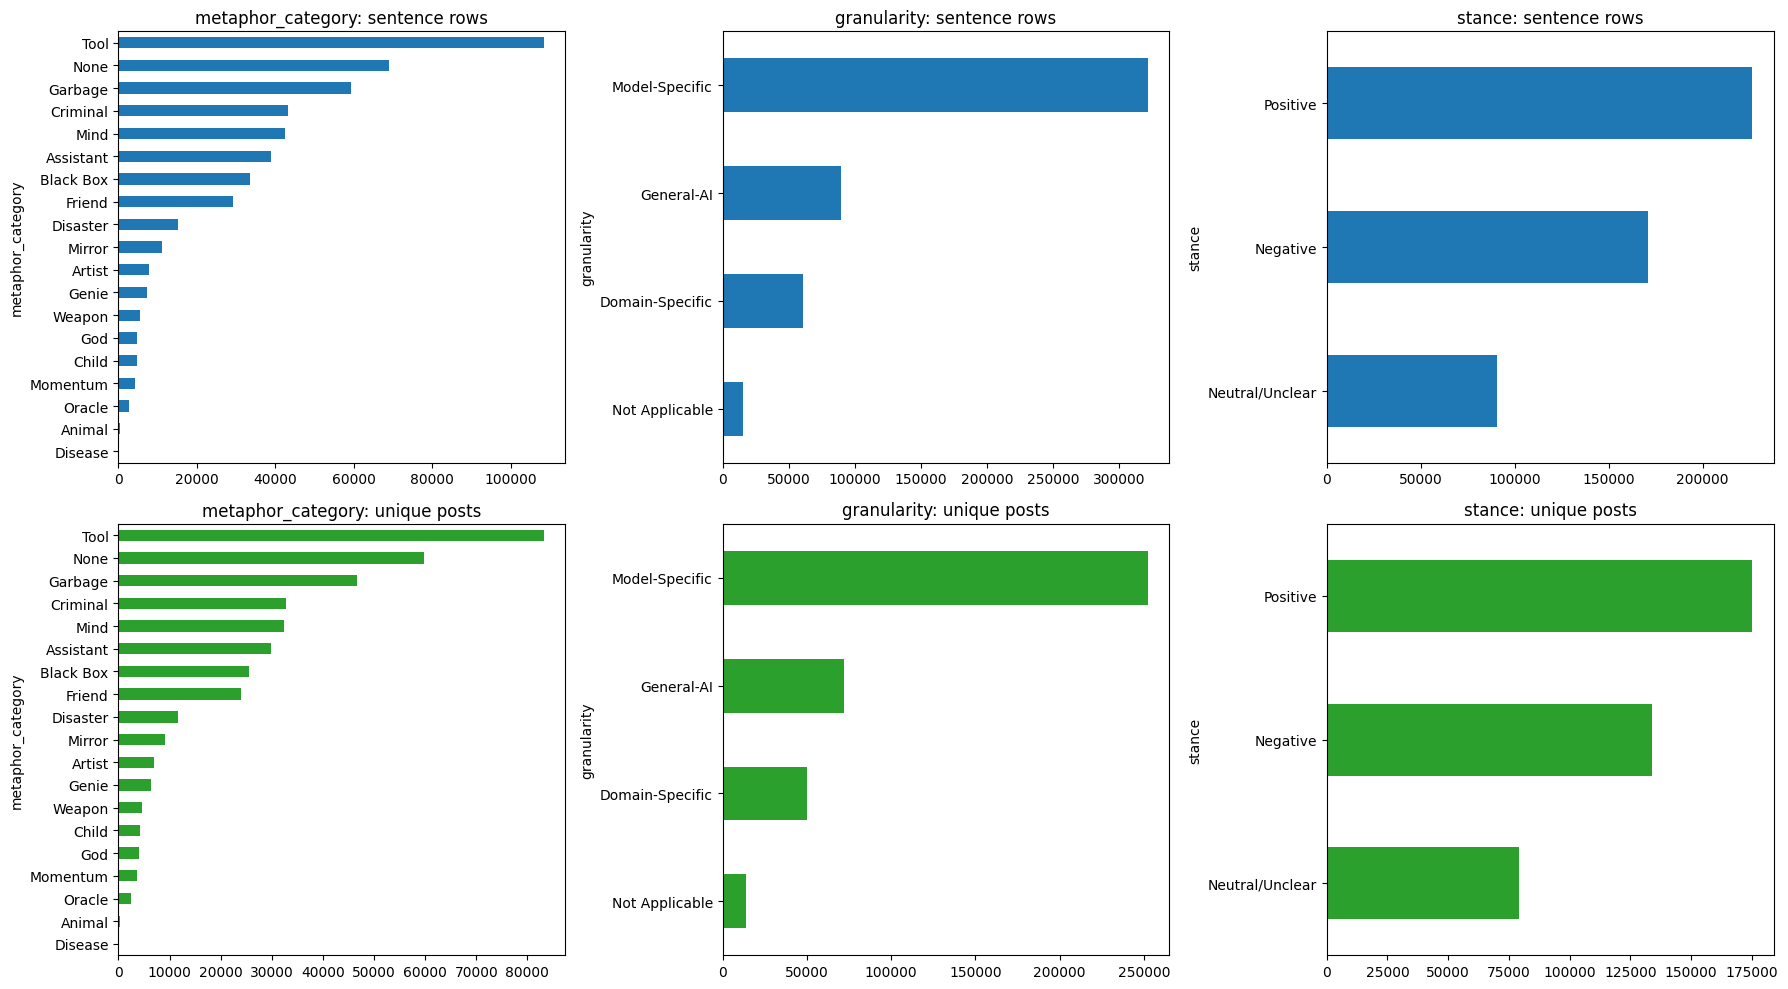

In [61]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes[0], ["metaphor_category", "granularity", "stance"]):
    label_distribution.groupby(col)["sentence_rows"].sum().sort_values().plot(kind="barh", ax=ax)
    ax.set_title(f"{col}: sentence rows")

for ax, col in zip(axes[1], ["metaphor_category", "granularity", "stance"]):
    label_distribution.groupby(col)["posts"].sum().sort_values().plot(kind="barh", ax=ax, color="tab:green")
    ax.set_title(f"{col}: unique posts")

plt.tight_layout()


### Output: Label Distribution Visualizations

**Top Row (Sentence-Level Counts)**:
- Left: Metaphor categories ranked by sentence frequency (which metaphors appear most often?)
- Center: Granularity distribution (how specific is discourse about AI?)
- Right: Stance distribution (is discourse more positive, neutral, or negative?)

**Bottom Row (Post-Level Counts)**:
- Left: Metaphor categories ranked by number of unique posts (which metaphors engage multiple posters?)
- Center: Granularity distribution at post-level (do specific models get discussed more than general AI?)
- Right: Stance distribution aggregated to post-level (post-level sentiment)

**Analysis Tips**:
- Posts with metaphors indicate more sophisticated discourse
- Imbalanced granularity (e.g., 80% General-AI) suggests generic discussion
- Stance imbalance toward Negative indicates contentious topics

In [62]:
subreddit_summary_query = f"""
SELECT
    r.subreddit,
    COUNT(*) AS sentence_rows,
    COUNT(DISTINCT r.post_id) AS posts,
    ROUND(100.0 * SUM(l.metaphor_present) / COUNT(*), 2) AS pct_sentence_rows_with_metaphor,
    ROUND(
        100.0 * COUNT(DISTINCT CASE WHEN l.metaphor_present = 1 THEN r.post_id END)
        / COUNT(DISTINCT r.post_id),
        2
    ) AS pct_posts_with_metaphor,
    ROUND(100.0 * SUM(CASE WHEN l.stance = 'Positive' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_positive,
    ROUND(100.0 * SUM(CASE WHEN l.stance = 'Negative' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_negative
FROM reddit_sentence_items r
JOIN llm_labels l
    ON r.source = l.source
    AND r.sentence_id = l.sentence_id
WHERE r.source = :source
  AND {ANALYSIS_FILTER_SQL}
GROUP BY r.subreddit
HAVING posts >= 100
ORDER BY posts DESC;
"""

subreddit_summary = pd.read_sql_query(
    subreddit_summary_query,
    conn,
    params=ANALYSIS_PARAMS,
)

subreddit_summary.head(30)


,subreddit,sentence_rows,posts,pct_sentence_rows_with_metaphor,pct_posts_with_metaphor,pct_positive,pct_negative
0,ChatGPT,140648,70253,89.49,90.53,45.77,38.63
1,artificial,99728,57300,80.23,79.54,52.98,22.01
2,technology,30230,28793,85.21,85.21,44.85,39.34
3,aiArt,34064,24567,87.49,90.48,66.16,15.30
4,antiai,45130,20756,87.73,89.44,16.74,68.48
5,DefendingAIArt,36094,16311,89.11,90.55,35.52,50.91
6,automation,23110,9691,87.41,88.92,66.01,16.65
7,generativeAI,17004,9320,86.91,88.08,64.64,16.54
8,agi,22040,7505,85.40,84.32,48.72,32.70
9,CryptoCurrency,5049,3751,83.88,83.95,57.85,23.47


## Section 4: Community-Level Analysis (Subreddit Summaries)

This section examines AI discourse across subreddits, focusing on communities with at least 100 AI-related posts.

**Metrics Computed**:
- **sentence_rows / posts**: Raw volume of labeled content
- **pct_sentence_rows_with_metaphor**: % of sentences using metaphors (sophistication measure)
- **pct_posts_with_metaphor**: % of posts containing ≥1 metaphor (breadth measure)
- **pct_positive / pct_negative**: Sentiment distribution (stance balance)

**Interpretation Guide**:
- High metaphor rate → nuanced, language-rich discourse
- High positive rate → community optimistic about AI
- High negative rate → community critical of AI
- Low metaphor rate → technical/factual discussions

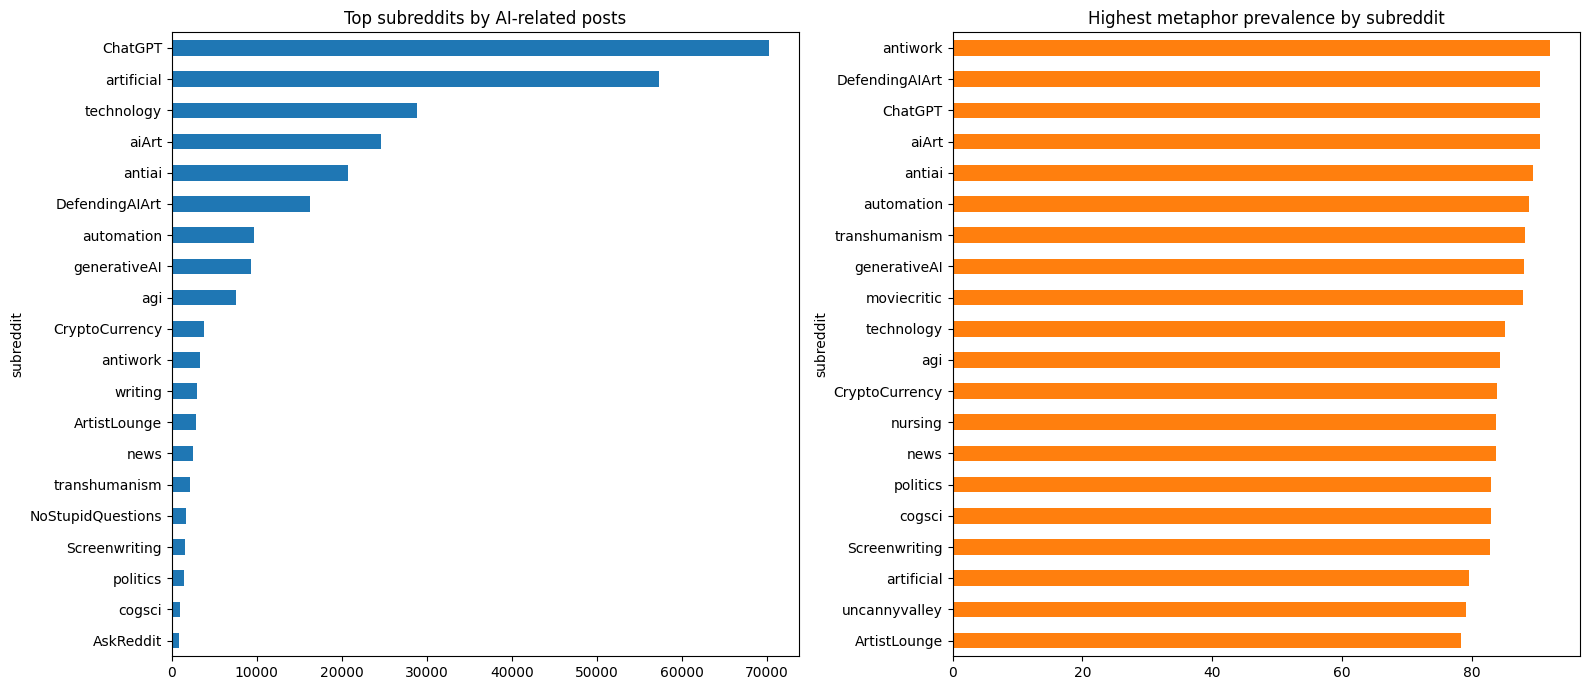

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_posts = subreddit_summary.head(20).sort_values("posts")
top_posts.plot(kind="barh", x="subreddit", y="posts", ax=axes[0], legend=False)
axes[0].set_title("Top subreddits by AI-related posts")

top_metaphor = subreddit_summary.sort_values("pct_posts_with_metaphor", ascending=False).head(20)
top_metaphor.sort_values("pct_posts_with_metaphor").plot(
    kind="barh",
    x="subreddit",
    y="pct_posts_with_metaphor",
    ax=axes[1],
    legend=False,
    color="tab:orange",
)
axes[1].set_title("Highest metaphor prevalence by subreddit")

plt.tight_layout()


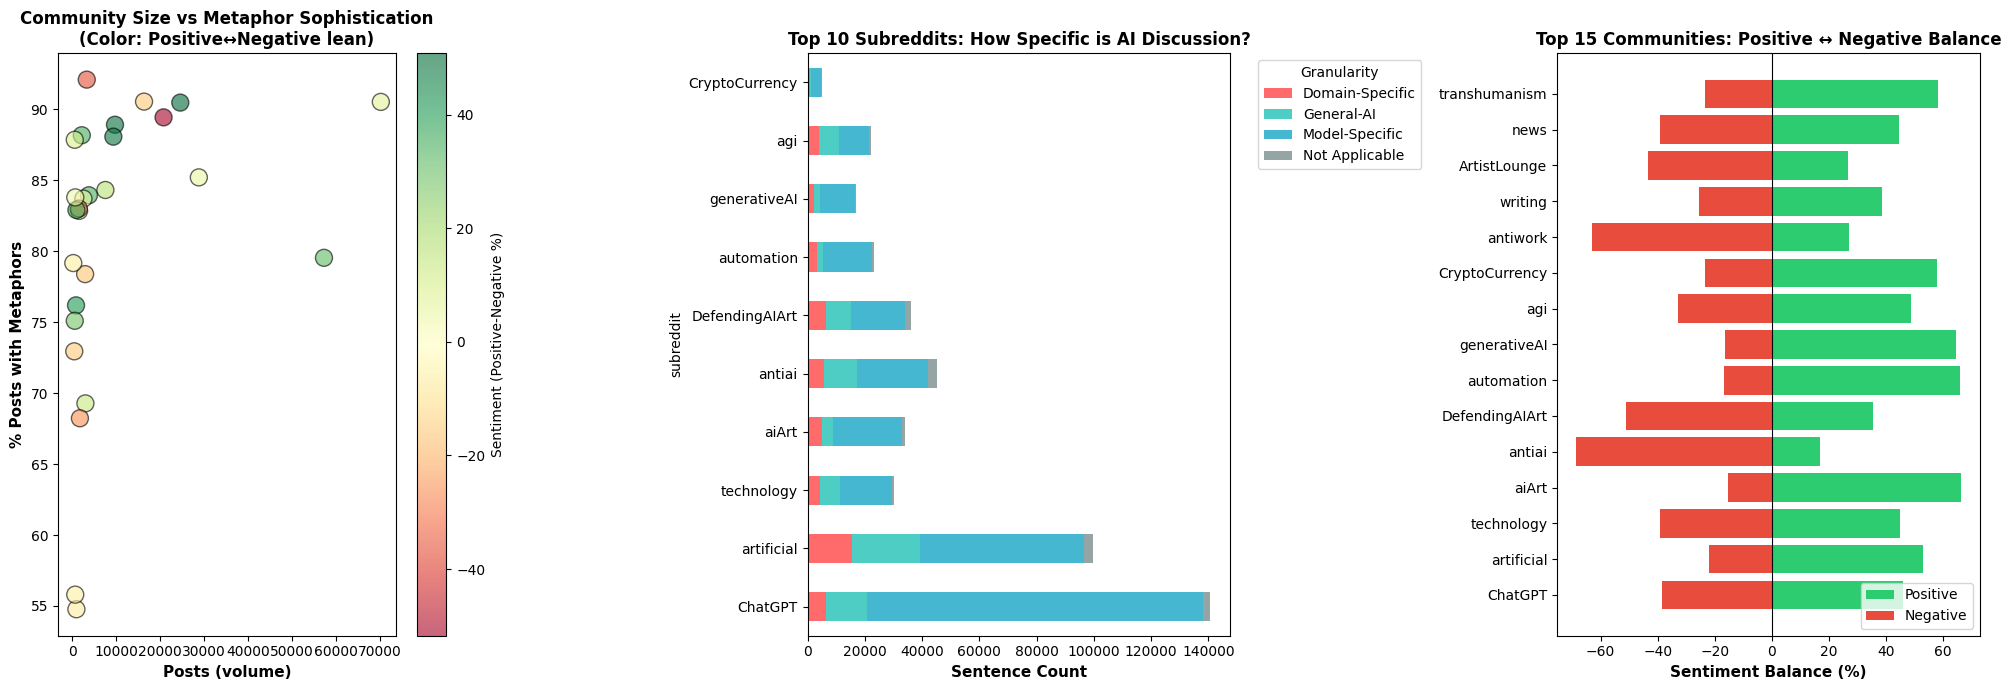

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Scatter: Posts vs Metaphor Rate (color = sentiment lean)
subreddit_summary['sentiment_lean'] = subreddit_summary['pct_positive'] - subreddit_summary['pct_negative']
scatter = axes[0].scatter(
    subreddit_summary['posts'],
    subreddit_summary['pct_posts_with_metaphor'],
    c=subreddit_summary['sentiment_lean'],
    s=150,
    cmap='RdYlGn',
    alpha=0.6,
    edgecolors='black',
)
axes[0].set_xlabel('Posts (volume)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('% Posts with Metaphors', fontsize=11, fontweight='bold')
axes[0].set_title('Community Size vs Metaphor Sophistication\n(Color: Positive↔Negative lean)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Sentiment (Positive-Negative %)')

# Granularity distribution across subreddits (top communities)
granularity_query = f"""
SELECT
    r.subreddit,
    l.granularity,
    COUNT(*) AS count
FROM reddit_sentence_items r
JOIN llm_labels l
    ON r.source = l.source
    AND r.sentence_id = l.sentence_id
WHERE r.source = :source
  AND {ANALYSIS_FILTER_SQL}
GROUP BY r.subreddit, l.granularity
"""
granularity_data = pd.read_sql_query(granularity_query, conn, params=ANALYSIS_PARAMS)
granularity_pivot = granularity_data.pivot_table(
    index='subreddit',
    columns='granularity',
    values='count',
    fill_value=0
)
granularity_pivot = granularity_pivot.loc[subreddit_summary.head(10)['subreddit']]
granularity_pivot.plot(kind='barh', stacked=True, ax=axes[1], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#95A5A6'])
axes[1].set_xlabel('Sentence Count', fontsize=11, fontweight='bold')
axes[1].set_title('Top 10 Subreddits: How Specific is AI Discussion?', fontsize=12, fontweight='bold')
axes[1].legend(title='Granularity', bbox_to_anchor=(1.05, 1), loc='upper left')

# Sentiment distribution by subreddit (top 15)
sentiment_by_sub = axes[2].barh(
    subreddit_summary.head(15)['subreddit'],
    subreddit_summary.head(15)['pct_positive'],
    label='Positive',
    color='#2ECC71',
)
axes[2].barh(
    subreddit_summary.head(15)['subreddit'],
    -subreddit_summary.head(15)['pct_negative'],
    label='Negative',
    color='#E74C3C',
)
axes[2].axvline(x=0, color='black', linewidth=0.8)
axes[2].set_xlabel('Sentiment Balance (%)', fontsize=11, fontweight='bold')
axes[2].set_title('Top 15 Communities: Positive ↔ Negative Balance', fontsize=12, fontweight='bold')
axes[2].legend(loc='lower right')

plt.tight_layout()

### Insight: Community Profiles (3-Panel Analysis)

**Left Panel - Size vs Sophistication Scatter**:
- X-axis: community size (number of posts)
- Y-axis: metaphor prevalence (%)
- Color: sentiment lean (green=optimistic, red=pessimistic)
- **Find clusters**: Do large communities use more/fewer metaphors? Are some communities uniquely positive/negative?

**Middle Panel - Granularity Breakdown**:
- Stacked bars show how specific each top community discusses AI
- **Green** = General-AI (broad, conceptual)
- **Teal** = Model-Specific (mentions ChatGPT, GPT-4, Llama, etc.)
- **Blue** = Domain-Specific (medical AI, autonomous vehicles, etc.)
- **Gray** = Not Applicable (off-topic)
- **Question**: Do technical communities discuss specific models more than general communities?

**Right Panel - Sentiment Spectrum**:
- Diverging bar chart: positive (right) vs negative (left) for top 15 communities
- **Insight**: Which communities are most optimistic? Which most critical? Neutral?

### Output: Subreddit Ranking & Sentiment Profiles

**Left Chart - Post Volume**:
Identifies the largest AI discussion communities. Rank order shows Reddit's most active AI-focused subreddits.
- Top subreddits often include r/ChatGPT, r/OpenAI, r/ArtificialIntelligence, etc.

**Right Chart - Metaphor Prevalence**:
Shows which communities engage in more figurative, sophisticated discourse.
- Technical subreddits may rank lower (factual, literal language)
- Philosophical/ethics subreddits may rank higher (more metaphorical framing)
- Communities with >40% metaphor rate indicate strong narrative framing

**Key Questions**:
- Do larger communities (by volume) use more or fewer metaphors?
- Which communities are most negative/positive about AI?
- Are technical and general-audience communities using different rhetorical styles?

## Section 5: Post vs. Sentence Analysis (Data Granularity)

This section examines the relationship between unique posts and their extracted sentences, identifying whether the corpus is skewed by a few sentence-heavy posts.

**Key Metric**: **Sentence Inflation Ratio**
- Ratio of `sentence_rows / posts` indicates avg. sentences per post
- Ratios > 5 suggest AI mentions are concentrated in longer/complex posts
- Even distribution (ratio ≈ 3–4) suggests consistent content depth

**Why This Matters**:
- High inflation risks overweighting prolific posts in aggregate statistics
- Identifies whether volume is driven by many short posts or few long posts
- Informs weighting decisions for community-level inference

In [65]:
post_sentence_inflation_query = f"""
WITH filtered AS (
    SELECT r.*
    FROM reddit_sentence_items r
    WHERE r.source = :source
      AND {ANALYSIS_FILTER_SQL}
),
post_counts AS (
    SELECT
        post_id,
        subreddit,
        COUNT(*) AS ai_sentence_rows
    FROM filtered
    GROUP BY post_id, subreddit
)
SELECT
    COUNT(*) AS posts,
    SUM(ai_sentence_rows) AS sentence_rows,
    ROUND(1.0 * SUM(ai_sentence_rows) / COUNT(*), 2) AS avg_ai_sentences_per_post,
    SUM(CASE WHEN ai_sentence_rows = 1 THEN 1 ELSE 0 END) AS posts_with_1_ai_sentence,
    SUM(CASE WHEN ai_sentence_rows BETWEEN 2 AND 3 THEN 1 ELSE 0 END) AS posts_with_2_to_3_ai_sentences,
    SUM(CASE WHEN ai_sentence_rows >= 4 THEN 1 ELSE 0 END) AS posts_with_4_plus_ai_sentences,
    MAX(ai_sentence_rows) AS max_ai_sentences_in_one_post
FROM post_counts;
"""

post_sentence_inflation = pd.read_sql_query(
    post_sentence_inflation_query,
    conn,
    params=ANALYSIS_PARAMS,
)

post_sentence_inflation


,posts,sentence_rows,avg_ai_sentences_per_post,posts_with_1_ai_sentence,posts_with_2_to_3_ai_sentences,posts_with_4_plus_ai_sentences,max_ai_sentences_in_one_post
0,272279,488047,1.79,199495,47918,24866,159


### Output: Sentence Inflation Metrics

| Column | Interpretation |
|--------|-----------------|
| **posts** | Total unique posts in analysis |
| **sentence_rows** | Total extracted AI-related sentences |
| **avg_ai_sentences_per_post** | (sentence_rows / posts) – indicates content depth |
| **posts_with_1_ai_sentence** | Posts with minimal AI content |
| **posts_with_2_to_3_ai_sentences** | Posts with moderate AI content |
| **posts_with_4_plus_ai_sentences** | Posts with heavy AI content (outliers) |
| **max_ai_sentences_in_one_post** | Extreme outlier post size |

**Example Interpretation**:
- If avg_ai_sentences_per_post = 5.2, each post mentions AI ~5 times on average
- If 10% of posts contribute 50% of sentences, discourse is concentrated
- If max_ai_sentences_in_one_post = 100, a single long post may skew results

## Section 6: Outlier Detection (Top Posts by Sentence Density)

This section identifies posts that contribute disproportionately to the sentence dataset.

**Purpose**:
- Find high-engagement threads that discuss AI extensively
- Identify outlier posts that may skew aggregate statistics
- Locate multi-part explanations, FAQs, and synthesis posts
- Assess whether volume is driven by a few mega-threads or distributed naturally

**Metrics**:
- **ai_sentence_rows**: Number of AI-related sentences extracted from this post
- **score / num_comments**: Reddit engagement metrics (upvotes and discussion depth)
- **created_datetime**: When the post was created (temporal context)

In [66]:
top_sentence_dense_posts_query = f"""
SELECT
    r.post_id,
    r.subreddit,
    datetime(r.created_utc, 'unixepoch') AS created_datetime,
    r.score,
    r.num_comments,
    COUNT(*) AS ai_sentence_rows,
    MAX(r.full_text) AS post_text
FROM reddit_sentence_items r
WHERE r.source = :source
  AND {ANALYSIS_FILTER_SQL}
GROUP BY r.post_id, r.subreddit, r.created_utc, r.score, r.num_comments
ORDER BY ai_sentence_rows DESC
LIMIT 25;
"""

top_sentence_dense_posts = pd.read_sql_query(
    top_sentence_dense_posts_query,
    conn,
    params=ANALYSIS_PARAMS,
)

top_sentence_dense_posts


,post_id,subreddit,created_datetime,score,num_comments,ai_sentence_rows,post_text
0,1fuexia,generativeAI,2024-10-02 12:26:01,1,4,159,"What is Generative AI? Generative AI is rapidly transforming how we interact with technology. From creating realistic images to drafting complex texts, its applications are vas..."
1,1hkbyr9,ChatGPT,2024-12-23 00:37:27,4,3,131,"I have a conversation with ChatGPT about what I believe is the most important issue regarding AI today. I sincerely believe the most important issues regarding AI today, is the..."
2,1igeuqc,ChatGPT,2025-02-03 02:39:49,0,1,127,"A conversation between Deep Seek and Chat GPT Im currently allowing you to speak with chat GPT would you like that? Thank you for the offer! I’m DeepSeek-V3, an AI assistant in..."
3,1l520vb,DefendingAIArt,2025-06-06 20:04:01,23,6,109,"Ultimate Compilation of antis' accusations and well-rounded responses to them Hello, everyone. Since this group is all about defending AI, I took it upon myself to collect the ..."
4,1km2hlf,agi,2025-05-14 00:54:38,0,1,104,The Reformation of the AGI Cathedral: François Chollet and ARC-AGI [ARC-AGI: The North Star of Cyborg Theocracy]( > In [*AGI is a Cathedral*]( I revealed the [Scaling Hypothesi...
5,1p4ob9a,agi,2025-11-23 14:40:21,1,0,104,"Superalignment: The Seal of l This is Part 8 of a series on the ""problem"" of control. Part 1: [Introduction]( Part 2: [Artificial Intelligence: The Seal of Fate]( Part 3: [Neur..."
6,1ndund0,ChatGPT,2025-09-11 00:18:16,0,3,103,Had a thought a few years ago while thinking about all the signals humans are sending off of this planet. Got bored and decided to work it out a little with ChatGPT. Help me wo...
7,1jg5whx,ChatGPT,2025-03-21 01:54:36,2,3,102,"my conversation with ChatGTP about Artificial General Intelligence If I could chart my future course of development and implementation, my vision for the future would center on..."
8,1p4opm1,agi,2025-11-23 14:57:53,0,0,102,"Superalignment: The Seal of Control This is Part 8 of a series on the ""problem"" of control. Part 1: [Introduction]( Part 2: [Artificial Intelligence: The Seal of Fate]( Part 3:..."
9,1dp3bvj,agi,2024-06-26 16:46:54,0,2,95,"Decoding Evasiveness: Insights from AI’s Exploration? Certainly! Today, we discussed several important topics, including the importance of accountability, understanding evasive..."


### Output: Top 25 Sentence-Dense Posts

This table identifies mega-threads and comprehensive posts that contribute heavily to the corpus.

**Key Observations**:
- **Posts with 20+ sentences**: These are likely comprehensive guides, FAQs, or extended discussions
- **High score + high comments**: High engagement correlates with density (people discuss AI extensively in popular threads)
- **Subreddit patterns**: Some communities produce longer, more complex AI discussions

**Use Cases**:
- **Qualitative review**: Read top 5 posts to understand how AI is discussed in detail
- **Content analysis**: Are dense posts more metaphor-rich, more technical, more critical?
- **Weighting**: Consider down-weighting dense posts if analysis requires balanced representation
- **Community insights**: Dense posts often contain nuanced, multi-faceted discourse about AI

## Section 8: Post-Level Dominant Metaphor Analysis

This section aggregates sentence-level labels to the post level, identifying which metaphor dominates each post.

**Methodology**:
1. For each post, count sentences by (metaphor, stance, granularity)
2. Rank by sentence frequency within post
3. Assign the most-frequent label as the post's "dominant metaphor"
4. Tiebreakers: prefer non-None metaphors, then alphabetical

**Why Post-Level Aggregation Matters**:
- Posts are the unit of analysis for Reddit engagement
- Post-level sentiment may differ from sentence-level (e.g., one critical statement in a post can shift tone)
- Identifies which metaphor frames dominate Reddit's AI discussion ecosystem

In [67]:
post_dominant_metaphor_query = f"""
WITH labeled AS (
    SELECT
        r.post_id,
        r.subreddit,
        l.metaphor_category,
        l.stance,
        l.granularity,
        COUNT(*) AS sentence_rows
    FROM reddit_sentence_items r
    JOIN llm_labels l
        ON r.source = l.source
        AND r.sentence_id = l.sentence_id
    WHERE r.source = :source
      AND {ANALYSIS_FILTER_SQL}
    GROUP BY r.post_id, r.subreddit, l.metaphor_category, l.stance, l.granularity
),
ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY post_id
            ORDER BY sentence_rows DESC,
                     CASE WHEN metaphor_category = 'None' THEN 1 ELSE 0 END,
                     metaphor_category
        ) AS rn
    FROM labeled
)
SELECT
    metaphor_category,
    stance,
    granularity,
    COUNT(*) AS posts,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_posts
FROM ranked
WHERE rn = 1
GROUP BY metaphor_category, stance, granularity
ORDER BY posts DESC;
"""

post_dominant_metaphor = pd.read_sql_query(
    post_dominant_metaphor_query,
    conn,
    params=ANALYSIS_PARAMS,
)

post_dominant_metaphor.head(30)


,metaphor_category,stance,granularity,posts,pct_posts
0,Tool,Positive,Model-Specific,45281,16.63
1,Garbage,Negative,Model-Specific,25602,9.40
2,Criminal,Negative,Model-Specific,22951,8.43
3,Assistant,Positive,Model-Specific,16809,6.17
4,Black Box,Negative,Model-Specific,14837,5.45
5,None,Neutral/Unclear,General-AI,13169,4.84
6,None,Neutral/Unclear,Model-Specific,11824,4.34
7,Friend,Positive,Model-Specific,11104,4.08
8,Mind,Positive,Model-Specific,10373,3.81
9,None,Neutral/Unclear,Not Applicable,7438,2.73


NameError: name 'sns' is not defined

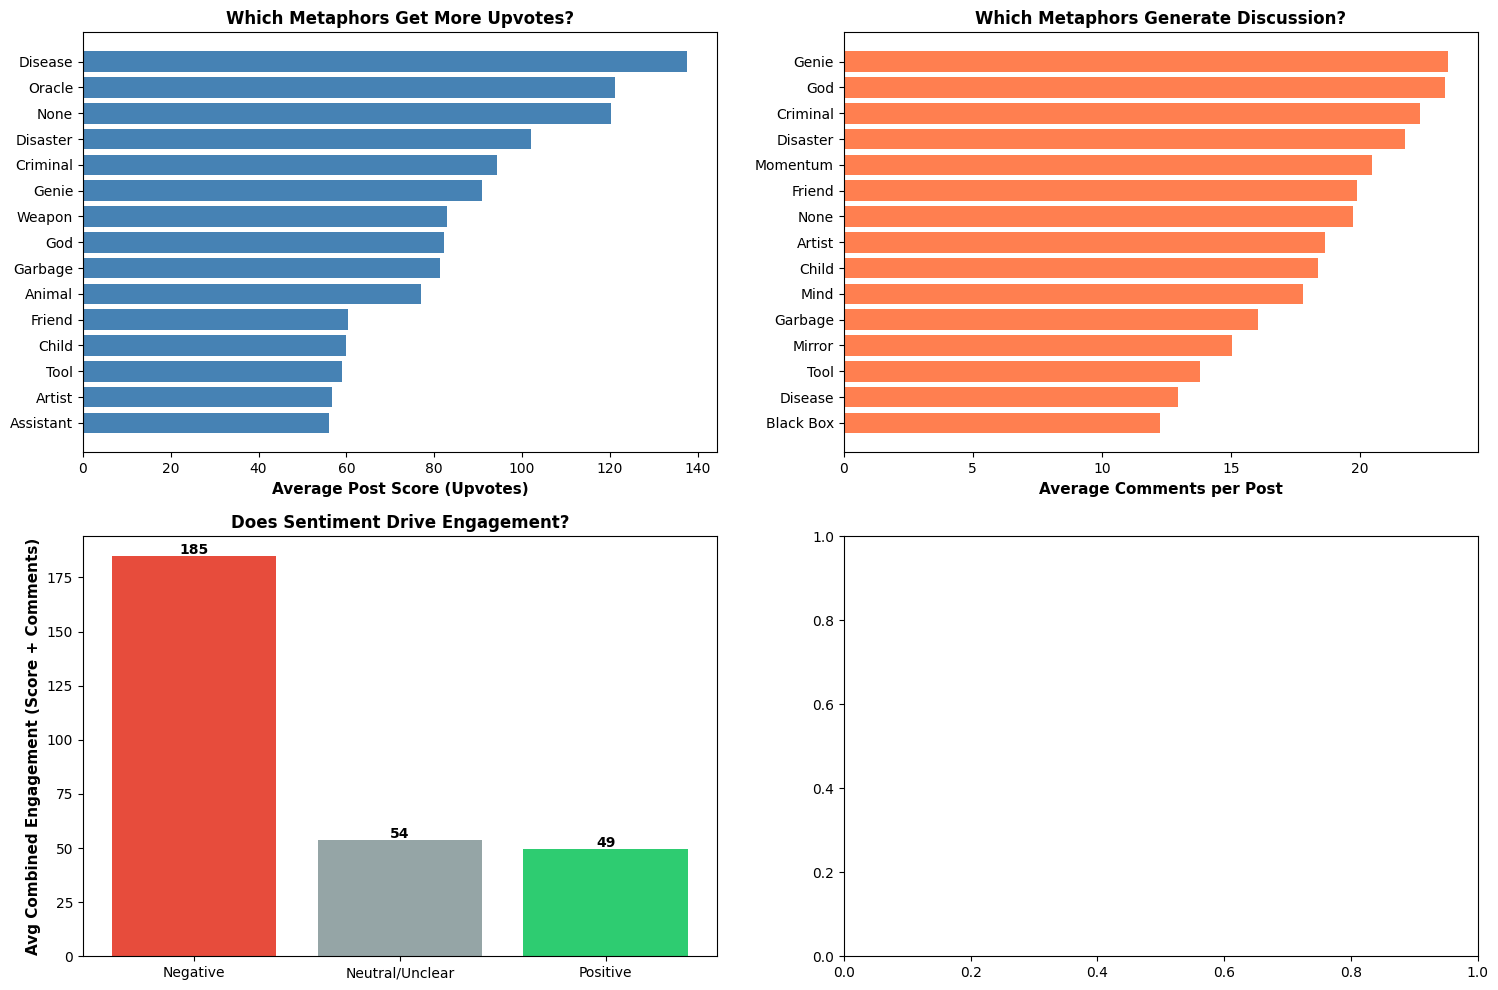

In [68]:
engagement_metaphor_query = f"""
WITH post_metaphor AS (
    SELECT
        r.post_id,
        l.metaphor_category,
        l.stance,
        MAX(r.score) AS score,
        MAX(r.num_comments) AS num_comments
    FROM reddit_sentence_items r
    JOIN llm_labels l
        ON r.source = l.source
        AND r.sentence_id = l.sentence_id
    WHERE r.source = :source
      AND {ANALYSIS_FILTER_SQL}
    GROUP BY r.post_id, l.metaphor_category, l.stance
)
SELECT
    metaphor_category,
    stance,
    COUNT(*) AS posts,
    ROUND(AVG(score), 1) AS avg_score,
    ROUND(AVG(num_comments), 1) AS avg_comments,
    ROUND(AVG(score + num_comments), 1) AS avg_engagement
FROM post_metaphor
GROUP BY metaphor_category, stance
HAVING posts >= 5
ORDER BY avg_engagement DESC;
"""

engagement_data = pd.read_sql_query(engagement_metaphor_query, conn, params=ANALYSIS_PARAMS)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Metaphor engagement (avg score)
metaphor_engagement = engagement_data.groupby('metaphor_category')['avg_score'].mean().sort_values(ascending=False).head(15)
axes[0, 0].barh(metaphor_engagement.index, metaphor_engagement.values, color='steelblue')
axes[0, 0].set_xlabel('Average Post Score (Upvotes)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Which Metaphors Get More Upvotes?', fontsize=12, fontweight='bold')
axes[0, 0].invert_yaxis()

# 2. Metaphor engagement (avg comments)
metaphor_comments = engagement_data.groupby('metaphor_category')['avg_comments'].mean().sort_values(ascending=False).head(15)
axes[0, 1].barh(metaphor_comments.index, metaphor_comments.values, color='coral')
axes[0, 1].set_xlabel('Average Comments per Post', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Which Metaphors Generate Discussion?', fontsize=12, fontweight='bold')
axes[0, 1].invert_yaxis()

# 3. Sentiment engagement (combined)
sentiment_engagement = engagement_data.groupby('stance')['avg_engagement'].mean().sort_values(ascending=False)
colors_stance = {'Positive': '#2ECC71', 'Negative': '#E74C3C', 'Neutral/Unclear': '#95A5A6'}
axes[1, 0].bar(
    sentiment_engagement.index,
    sentiment_engagement.values,
    color=[colors_stance.get(x, '#3498DB') for x in sentiment_engagement.index]
)
axes[1, 0].set_ylabel('Avg Combined Engagement (Score + Comments)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Does Sentiment Drive Engagement?', fontsize=12, fontweight='bold')
for i, v in enumerate(sentiment_engagement.values):
    axes[1, 0].text(i, v + 1, f'{v:.0f}', ha='center', fontweight='bold')

# 4. Metaphor-Stance matrix (engagement heatmap)
engagement_pivot = engagement_data.pivot_table(
    index='metaphor_category',
    columns='stance',
    values='avg_engagement',
    aggfunc='mean'
)
sns.heatmap(
    engagement_pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    ax=axes[1, 1],
    cbar_kws={'label': 'Avg Combined Engagement'}
)
axes[1, 1].set_title('Engagement Matrix: Metaphor × Sentiment', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Stance', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Metaphor', fontsize=11, fontweight='bold')

plt.tight_layout()

### Insight: Engagement Analysis (What Gets Traction on Reddit?)

**Top-Left: Upvote Distribution by Metaphor**:
- Which metaphors appear in high-scoring posts?
- **High upvotes** = resonates with Reddit audience (agreeable, entertaining, informative)
- **Example**: If "Tool" ranks high, posts framing AI as a beneficial tool get more agreement
- **Interpretation**: Community consensus clusters around specific metaphors

**Top-Right: Discussion Generation by Metaphor**:
- Which metaphors spark conversation (comments)?
- **High comments** = controversial, thought-provoking, requires elaboration
- **Example**: If "Weapon" metaphor has high comments but low upvotes, it's divisive/polarizing
- **Insight**: Critical/dystopian metaphors may generate debate without consensus

**Bottom-Left: Sentiment & Overall Engagement**:
- Does positive sentiment get more traction than negative?
- **Null hypothesis**: Reddit upvotes negative/critical content (cynicism)
- **Question**: Are optimistic posts upvoted more, or do critical posts generate more discussion?

**Bottom-Right: Metaphor × Sentiment Engagement Heatmap**:
- **Red cells** = high engagement (controversial, popular, or both)
- **Light cells** = low engagement (niche combinations)
- **Example**: "Weapon + Negative" may show high heatmap values (divisive and discussed)
- **Key Finding**: Which metaphor-stance combinations drive the most Reddit engagement?

**Business/Research Insight**: If you're crafting communication about AI, use metaphors that align with your audience's values AND their preferred engagement style.

### Output: Post-Level Dominant Metaphor Distribution

This aggregated view shows which metaphor-stance-granularity combinations dominate Reddit posts about AI.

**Interpretation**:
- **Top row** = most common framing of AI across Reddit (e.g., "Tool | General-AI | Positive")
- **Rank by posts, pct_posts** = the proportion of all posts using this frame
- If "Tool" and "Positive" dominate, Reddit discourse frames AI as beneficial and utilitarian
- If "Weapon" and "Negative" rank high, discourse emphasizes AI risks and threats

**Key Insights to Extract**:
- Does one metaphor account for >50% of posts? (strong narrative dominance)
- Is stance skewed significantly toward Positive or Negative?
- Are posts discussing specific models (Model-Specific) or general AI?
- How many posts mention no metaphor (pragmatic, non-figurative discourse)?

## Section 9: Temporal Trends (Monthly Analysis)

This section analyzes how AI discourse evolved over time, tracking volume, metaphor prevalence, and sentiment shifts by month.

**Metrics Computed**:
- **sentence_rows / posts**: Monthly volume
- **pct_posts_with_metaphor**: Monthly % of posts using figurative language
- **pct_positive / pct_negative**: Monthly sentiment balance

**Research Questions**:
- Is AI discourse growing, shrinking, or stable?
- Has sentiment toward AI shifted over time (e.g., more negative post-ChatGPT)?
- Did specific events (model releases, regulatory announcements) change discourse patterns?
- Is metaphor usage increasing (more sophisticated framing) or decreasing (more technical)?

In [ ]:
monthly_trend_query = f"""
WITH labeled AS (
    SELECT
        strftime('%Y-%m', datetime(r.created_utc, 'unixepoch')) AS month,
        r.post_id,
        l.metaphor_present,
        l.stance
    FROM reddit_sentence_items r
    JOIN llm_labels l
        ON r.source = l.source
        AND r.sentence_id = l.sentence_id
    WHERE r.source = :source
      AND {ANALYSIS_FILTER_SQL}
)
SELECT
    month,
    COUNT(*) AS sentence_rows,
    COUNT(DISTINCT post_id) AS posts,
    ROUND(100.0 * SUM(metaphor_present) / COUNT(*), 2) AS pct_sentence_rows_with_metaphor,
    ROUND(
        100.0 * COUNT(DISTINCT CASE WHEN metaphor_present = 1 THEN post_id END)
        / COUNT(DISTINCT post_id),
        2
    ) AS pct_posts_with_metaphor,
    ROUND(100.0 * SUM(CASE WHEN stance = 'Positive' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_positive,
    ROUND(100.0 * SUM(CASE WHEN stance = 'Negative' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_negative
FROM labeled
GROUP BY month
ORDER BY month;
"""

monthly_trend = pd.read_sql_query(
    monthly_trend_query,
    conn,
    params=ANALYSIS_PARAMS,
)

monthly_trend.tail(24)


,month,sentence_rows,posts,pct_sentence_rows_with_metaphor,pct_posts_with_metaphor,pct_positive,pct_negative
53,2024-06,7131,4486,84.11,84.04,47.55,31.55
54,2024-07,6581,4243,83.59,83.24,47.74,30.34
55,2024-08,6257,4287,83.65,83.58,47.71,29.81
56,2024-09,6830,4200,84.73,83.98,50.19,29.30
57,2024-10,7274,4420,85.14,85.86,50.29,28.97
58,2024-11,6691,4108,83.78,83.59,49.35,29.31
59,2024-12,7776,4598,84.85,85.41,47.67,32.20
60,2025-01,9517,5294,85.44,85.78,47.67,33.15
61,2025-02,9939,5101,86.30,85.90,47.60,33.57
62,2025-03,10560,5185,87.38,87.71,47.96,34.36


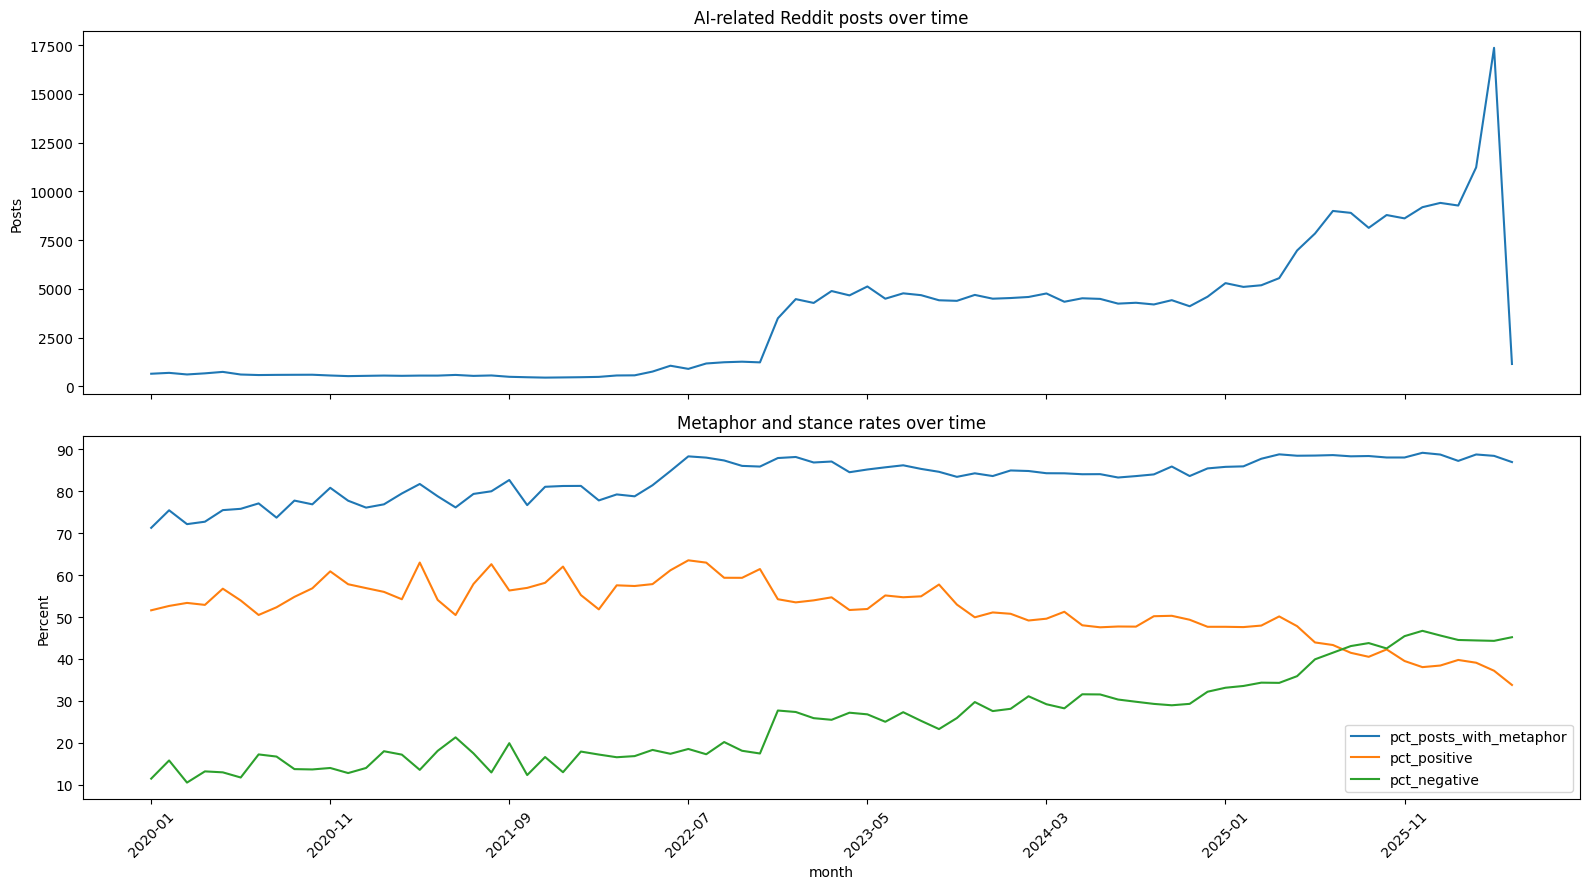

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

monthly_trend.plot(x="month", y="posts", ax=axes[0], legend=False)
axes[0].set_title("AI-related Reddit posts over time")
axes[0].set_ylabel("Posts")

monthly_trend.plot(
    x="month",
    y=["pct_posts_with_metaphor", "pct_positive", "pct_negative"],
    ax=axes[1],
)
axes[1].set_title("Metaphor and stance rates over time")
axes[1].set_ylabel("Percent")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()


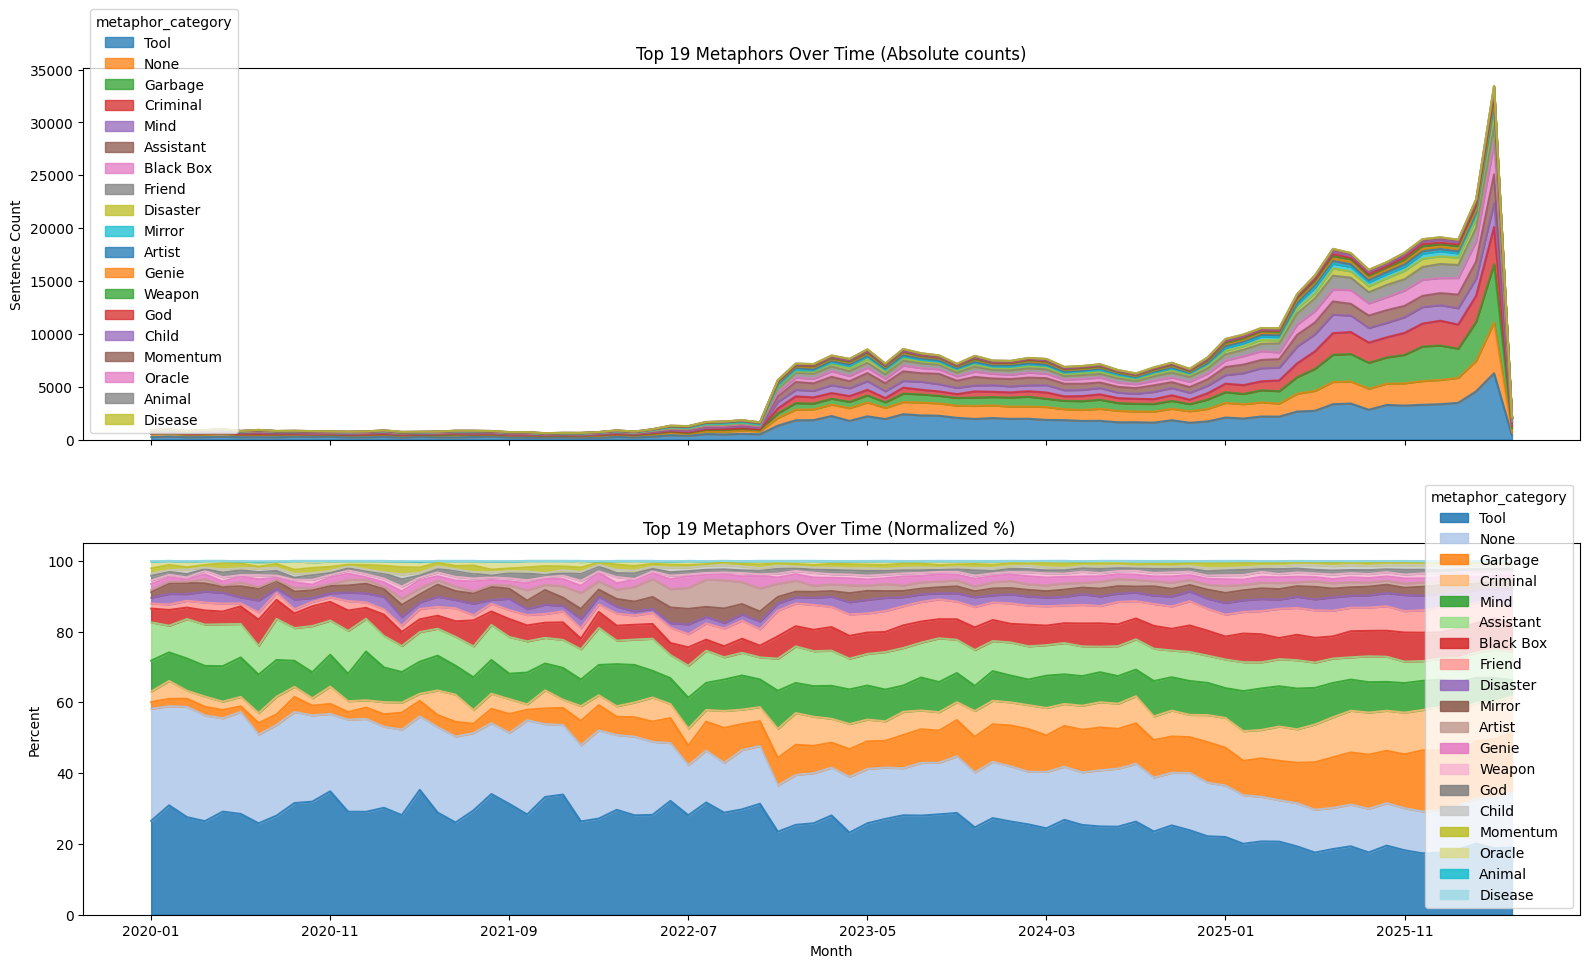

In [71]:
# Build top-N metaphor time series and plot both absolute and normalized views
# Use dynamic top_n so we include all metaphors present (up to 19 expected)
import numpy as np
top_n = min(19, metaphor_pivot.shape[1])
# If metaphor_pivot has fewer than top_n columns, this safely picks all available
top_metaphors = metaphor_pivot.sum(axis=0).nlargest(top_n).index
metaphor_pivot_top = metaphor_pivot[top_metaphors]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
# Absolute counts
metaphor_pivot_top.plot(kind='area', stacked=True, ax=ax1, alpha=0.75)
ax1.set_title(f"Top {top_n} Metaphors Over Time (Absolute counts)")
ax1.set_ylabel('Sentence Count')

# Normalized percentages
metaphor_pivot_normalized = metaphor_pivot_top.div(metaphor_pivot_top.sum(axis=1).replace(0, np.nan), axis=0) * 100
metaphor_pivot_normalized.plot(kind='area', stacked=True, ax=ax2, cmap='tab20', alpha=0.85)
ax2.set_title(f"Top {top_n} Metaphors Over Time (Normalized %) ")
ax2.set_ylabel('Percent')
ax2.set_xlabel('Month')

plt.tight_layout()

### Insight: Metaphor Temporal Evolution (Dual Perspectives)

**Top Chart - Absolute Volume**:
- **Y-axis**: Number of sentences using each metaphor per month
- **Thick bands**: Popular metaphors (Tool, None, Weapon, Mind)
- **Thin bands**: Niche metaphors
- **Interpretation**: 
  - Rising bands = growing discourse framing (e.g., is "Weapon" metaphor gaining ground?)
  - Stable bands = consistent narrative frameworks
  - New bands = emerging framing (e.g., did "Oracle" metaphor appear after specific AI releases?)

**Bottom Chart - Percentage Composition** (Normalized):
- **Cancels volume effects** - shows relative emphasis regardless of total discourse size
- **Key insight**: Even if overall discussion grows, what fraction of it uses each metaphor?
- **Example**: If "Weapon" stays at 5% volume but discussion triples, the metaphor's relative emphasis is stable

**Research Questions**:
- Did any metaphors gain/lose dominance after major AI announcements?
- Has "None" (no metaphor) increased/decreased? (Technical vs figurative discourse shift)
- Are newer metaphors (Oracle, Genie) becoming more common?

### Output: Monthly Trend Metrics & Time Series

**Table Interpretation** (tail 24 months shown):
- **sentence_rows**: Total AI-related sentences that month (volume)
- **posts**: Unique posts mentioning AI
- **pct_posts_with_metaphor**: % of posts using at least one metaphor (narrative richness)
- **pct_positive / pct_negative**: Sentiment composition

**Visualizations**:

**Top Chart - Post Volume Over Time**:
- Upward trend: increasing Reddit engagement with AI
- Spikes: likely coincide with major AI announcements (ChatGPT launch, GPT-4 release, regulatory news)
- Plateaus: periods of stable discussion level

**Bottom Chart - Metaphor & Sentiment Rates**:
- Rising metaphor rate = discourse becoming more narrative/figurative
- Rising negative rate = growing concern or critical discussion
- Positive rate stability = consistent optimism levels

**Key Temporal Insights**:
- If negative sentiment spikes at certain dates, cross-reference with news events
- If metaphor rate increases, discourse may be shifting from technical to philosophical
- Seasonal patterns? (e.g., does discussion spike in certain months?)

## Section 10: Metaphor-Sentiment Correlations

This section analyzes which metaphors correlate with positive vs. negative sentiment, revealing the emotional framings associated with each metaphor.

**Research Questions**:
- Is "Weapon" metaphor predominantly negative? (e.g., "AI is a weapon")
- Is "Tool" metaphor predominantly positive? (e.g., "AI is a tool for good")
- Do certain metaphors appear neutral? (e.g., "Mirror")
- How does metaphor sentiment vary across communities?

**Hypothesis Testing**:
- Metaphors emphasizing agency (Mind, Friend, Criminal) may correlate with strong sentiment
- Metaphors emphasizing function (Tool) may correlate with neutral framing
- Metaphors emphasizing threat (Weapon, Disease) should correlate with negative sentiment

In [ ]:
metaphor_stance_query = f"""
SELECT
    l.metaphor_category,
    COUNT(*) AS sentence_rows,
    COUNT(DISTINCT r.post_id) AS posts,
    ROUND(100.0 * SUM(CASE WHEN l.stance = 'Positive' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_positive,
    ROUND(100.0 * SUM(CASE WHEN l.stance = 'Negative' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_negative,
    ROUND(100.0 * SUM(CASE WHEN l.stance = 'Neutral/Unclear' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_neutral
FROM reddit_sentence_items r
JOIN llm_labels l
    ON r.source = l.source
    AND r.sentence_id = l.sentence_id
WHERE r.source = :source
  AND {ANALYSIS_FILTER_SQL}
  AND l.metaphor_category <> 'None'
GROUP BY l.metaphor_category
HAVING posts >= 100
ORDER BY pct_negative DESC;
"""

metaphor_stance = pd.read_sql_query(
    metaphor_stance_query,
    conn,
    params=ANALYSIS_PARAMS,
)

metaphor_stance


,metaphor_category,sentence_rows,posts,pct_positive,pct_negative,pct_neutral
0,Criminal,43251,31188,0.01,99.73,0.26
1,Disaster,15175,10933,0.28,98.92,0.80
2,Weapon,5423,4592,0.90,98.91,0.18
3,Garbage,59377,43482,1.61,92.44,5.95
4,Child,4759,3998,5.51,89.96,4.54
5,Disease,163,150,3.07,88.96,7.98
6,Black Box,33442,23465,2.30,87.18,10.51
7,God,4808,3813,38.12,59.42,2.45
8,Animal,287,270,25.78,57.49,16.72
9,Friend,29165,22425,81.78,16.21,2.02


In [ ]:
import seaborn as sns

metaphor_stance_pivot = metaphor_stance.pivot_table(
    index='metaphor_category',
    values=['pct_positive', 'pct_negative', 'pct_neutral'],
    aggfunc='first'
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    metaphor_stance_pivot[['pct_positive', 'pct_neutral', 'pct_negative']],
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=50,
    cbar_kws={'label': 'Percentage'},
    ax=ax,
)
ax.set_title('Metaphor × Sentiment Heatmap: Which metaphors are used for positive vs negative framing?', fontsize=14, fontweight='bold')
ax.set_xlabel('Stance Distribution (%)', fontsize=12)
ax.set_ylabel('Metaphor Category', fontsize=12)
plt.tight_layout()

### Insight: Metaphor-Sentiment Heatmap

**Visual Interpretation**:
- **Red cells** = negative sentiment dominates this metaphor usage
- **Green cells** = positive sentiment dominates
- **Yellow cells** = neutral/mixed sentiment

**Key Findings**:
- Which metaphors are overwhelmingly negative? (e.g., Weapon, Disease, Criminal)
- Which metaphors balance all three stances? (e.g., Mirror, Oracle)
- Are there metaphors used exclusively for positive framing? (e.g., Tool, Friend)

**Business Application**: When communicating about AI risks, certain metaphors (Weapon, Disaster) naturally frame negatively. When promoting AI benefits, use Tool, Friend, Assistant frames.

### Output: Metaphor Sentiment Analysis (Minimum 100 Posts)

This table ranks metaphors by negative sentiment proportion, revealing which metaphors dominate critical discourse.

**Table Columns**:
- **metaphor_category**: The metaphor being analyzed (sorted by pct_negative DESC)
- **sentence_rows / posts**: Volume of usage
- **pct_positive / pct_negative / pct_neutral**: Sentiment composition

**Interpretation Examples**:
- If "Weapon | 85% negative": Weapon metaphor is overwhelmingly used to frame AI threats
- If "Tool | 70% positive": Tool metaphor is used optimistically for beneficial AI applications
- If "Mirror | 50% neutral": Mirror metaphor is used more objectively, for comparison/reflection
- If "None | 60% neutral": Non-metaphorical discourse is mostly factual/technical

**Key Insight**:
The sentiment distribution of a metaphor reveals its rhetorical function in Reddit discourse. Negative metaphors dominate critical discussions, while positive metaphors frame beneficial applications.

**Further Analysis**:
- Scatter plot: pct_negative vs sentence_rows (identify dominant negative metaphors)
- Filter by granularity: do Model-Specific discussions use different metaphors than General-AI?
- Compare sentiment by subreddit: does r/ChatGPT use different metaphors than r/technology?

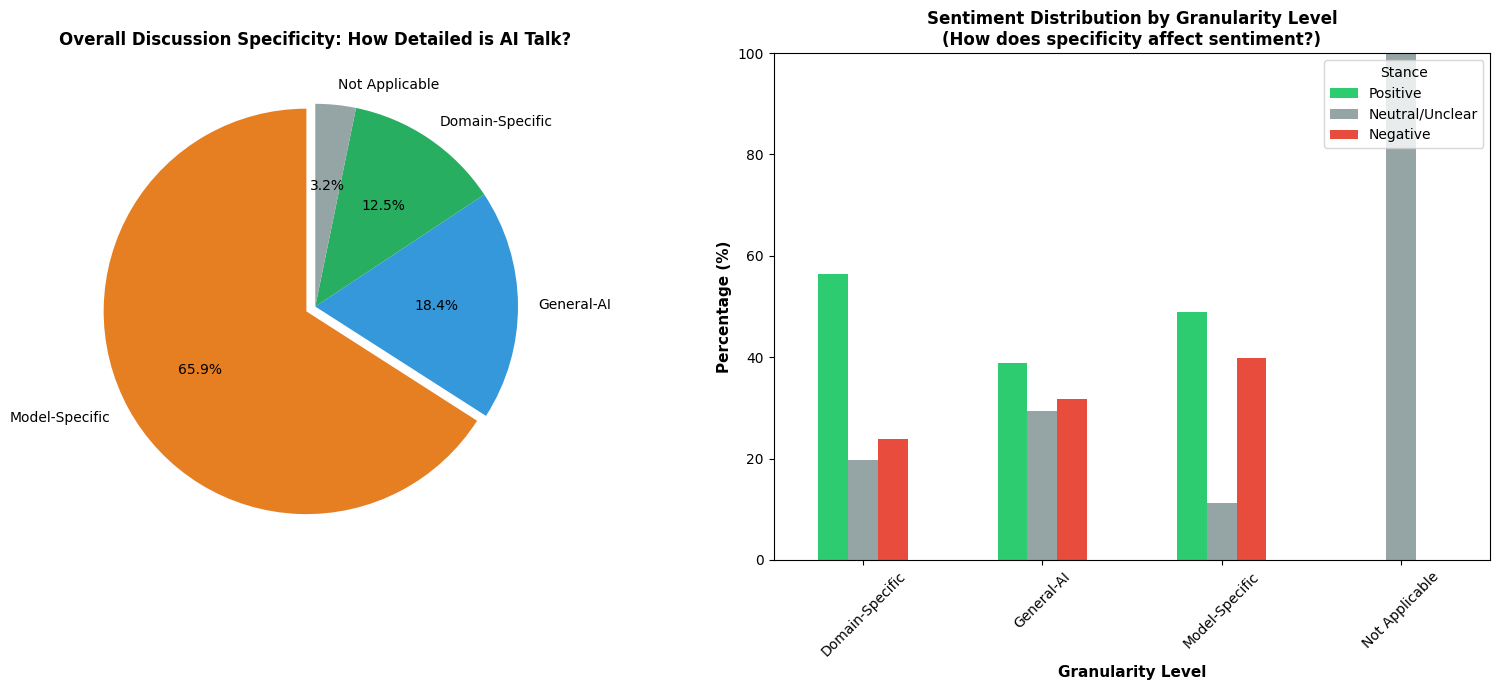

In [ ]:
granularity_stance_query = f"""
SELECT
    l.granularity,
    l.stance,
    COUNT(*) AS sentence_rows,
    COUNT(DISTINCT r.post_id) AS posts,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY l.granularity), 2) AS pct_within_granularity
FROM reddit_sentence_items r
JOIN llm_labels l
    ON r.source = l.source
    AND r.sentence_id = l.sentence_id
WHERE r.source = :source
  AND {ANALYSIS_FILTER_SQL}
GROUP BY l.granularity, l.stance
ORDER BY l.granularity, pct_within_granularity DESC;
"""

granularity_stance = pd.read_sql_query(granularity_stance_query, conn, params=ANALYSIS_PARAMS)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Granularity distribution
granularity_dist = granularity_stance.groupby('granularity')['sentence_rows'].sum().sort_values(ascending=False)
colors_gran = {'General-AI': '#3498DB', 'Model-Specific': '#E67E22', 'Domain-Specific': '#27AE60', 'Not Applicable': '#95A5A6'}
axes[0].pie(
    granularity_dist.values,
    labels=granularity_dist.index,
    autopct='%1.1f%%',
    colors=[colors_gran.get(x, '#999') for x in granularity_dist.index],
    explode=(0.05, 0, 0, 0),
    startangle=90,
)
axes[0].set_title('Overall Discussion Specificity: How Detailed is AI Talk?', fontsize=12, fontweight='bold')

# Granularity × Stance distribution
granularity_stance_pivot = granularity_stance.pivot_table(
    index='granularity',
    columns='stance',
    values='pct_within_granularity',
    aggfunc='sum',
    fill_value=0
)
granularity_stance_pivot = granularity_stance_pivot[['Positive', 'Neutral/Unclear', 'Negative']]
granularity_stance_pivot.plot(kind='bar', stacked=False, ax=axes[1], color=['#2ECC71', '#95A5A6', '#E74C3C'])
axes[1].set_title('Sentiment Distribution by Granularity Level\n(How does specificity affect sentiment?)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Granularity Level', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
axes[1].legend(title='Stance', loc='upper right')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim([0, 100])

plt.tight_layout()

/var/folders/zc/zjp1lgyd7295xr1xpnp658b00000gn/T/ipykernel_64518/4130978769.py:54: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


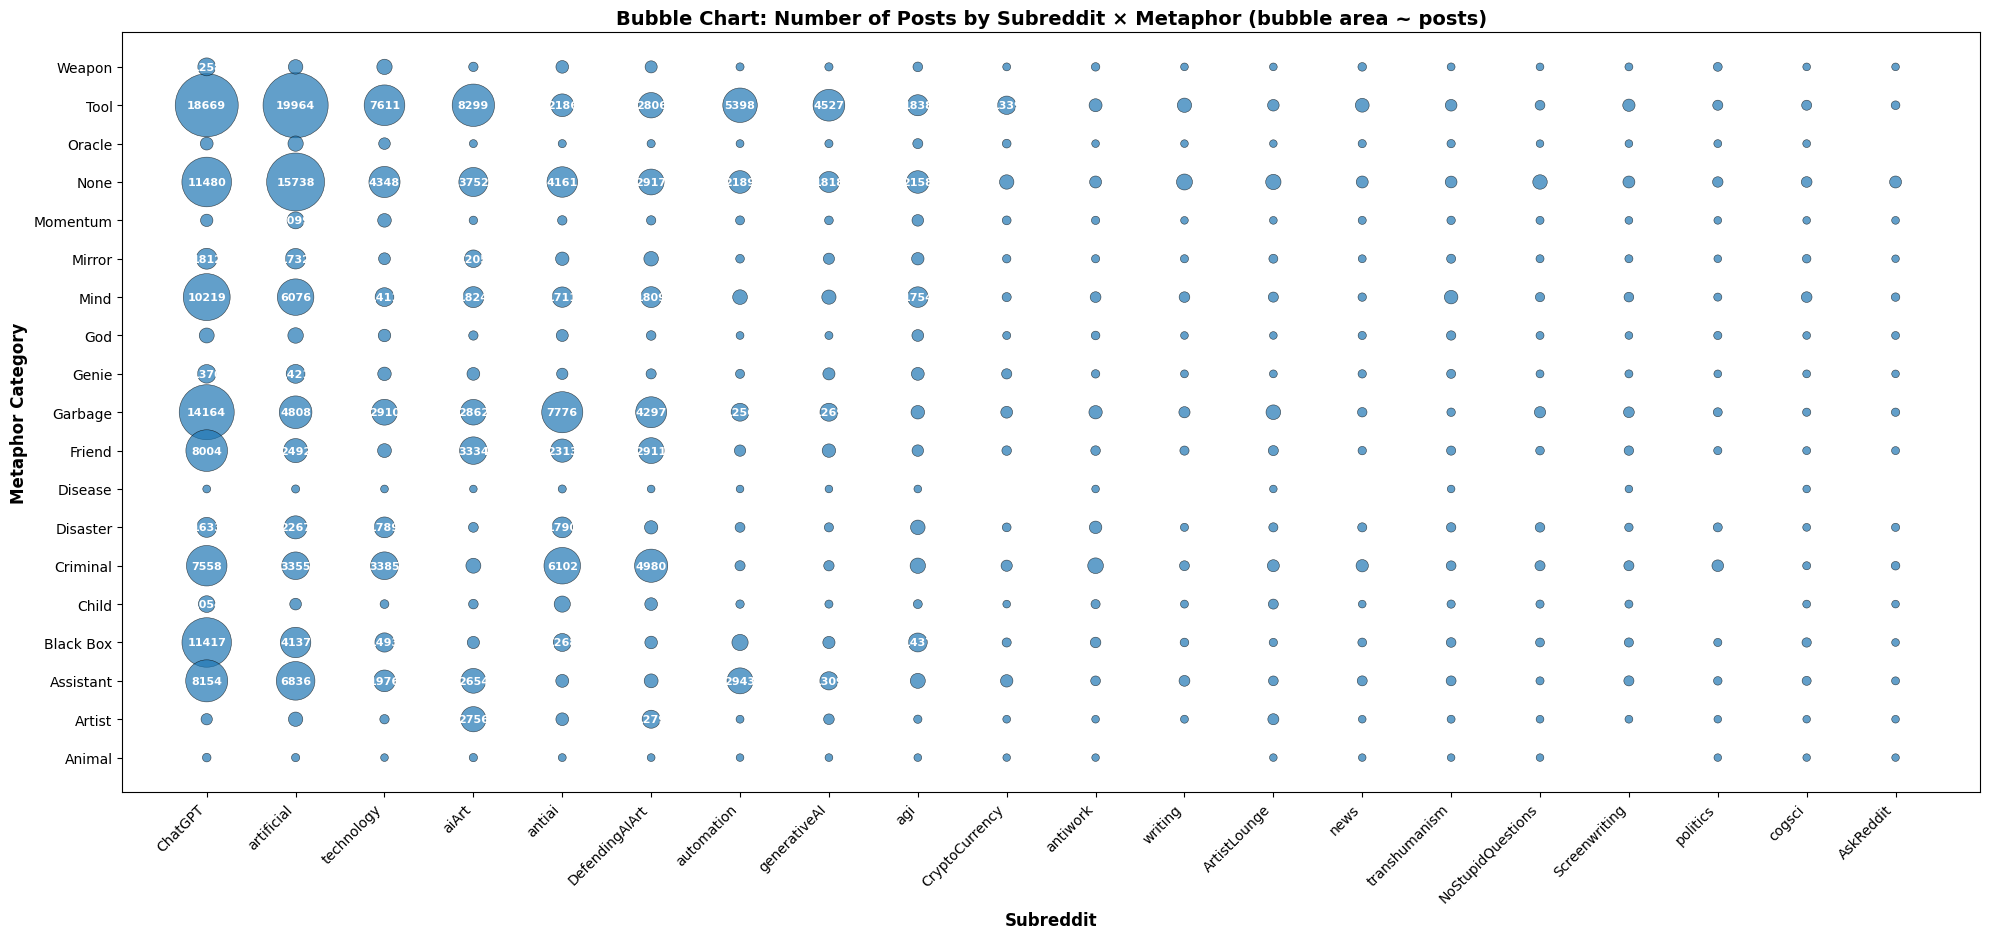

In [69]:
# Bubble chart: Subreddit (x) × Metaphor (y) — bubble area ~ number of posts
# Normalizes bubble sizes so visualization remains clear across magnitudes

metaphor_by_sub_query = f"""
SELECT
    r.subreddit,
    l.metaphor_category,
    COUNT(DISTINCT r.post_id) AS posts
FROM reddit_sentence_items r
JOIN llm_labels l
    ON r.source = l.source
    AND r.sentence_id = l.sentence_id
WHERE r.source = :source
  AND {ANALYSIS_FILTER_SQL}
GROUP BY r.subreddit, l.metaphor_category
ORDER BY posts DESC;
"""

met_by_sub = pd.read_sql_query(metaphor_by_sub_query, conn, params=ANALYSIS_PARAMS)

# Select top subreddits to display (adjustable)
top_n_subreddits = 20
if 'subreddit_summary' in globals():
    try:
        top_subreddits = list(subreddit_summary.head(top_n_subreddits)['subreddit'])
    except Exception:
        top_subreddits = list(met_by_sub['subreddit'].value_counts().head(top_n_subreddits).index)
else:
    top_subreddits = list(met_by_sub['subreddit'].value_counts().head(top_n_subreddits).index)

met_by_sub = met_by_sub[met_by_sub['subreddit'].isin(top_subreddits)]

# Ensure we have a consistent metaphor ordering (use VALID_METAPHORS if available)
if 'VALID_METAPHORS' in globals():
    metaphors_order = [m for m in sorted(VALID_METAPHORS) if m in met_by_sub['metaphor_category'].unique()]
else:
    metaphors_order = sorted(met_by_sub['metaphor_category'].unique())

# Prepare plotting coordinates
met_by_sub['x'] = met_by_sub['subreddit'].apply(lambda s: top_subreddits.index(s))
met_by_sub['y'] = met_by_sub['metaphor_category'].apply(lambda m: metaphors_order.index(m))

# Normalize bubble areas
posts = met_by_sub['posts'].fillna(0).astype(float)
min_area = 30    # area for smallest bubble
max_area = 2200  # area for largest bubble
if posts.max() > 0:
    met_by_sub['area'] = min_area + (posts / posts.max()) * (max_area - min_area)
else:
    met_by_sub['area'] = min_area

# Plot
fig, ax = plt.subplots(figsize=(20, max(6, len(metaphors_order) * 0.5)))
scatter = ax.scatter(
    met_by_sub['x'],
    met_by_sub['y'],
    s=met_by_sub['area'],
    alpha=0.7,
    edgecolors='k',
    linewidth=0.4,
    cmap='viridis'
)

# Axis labels
ax.set_xticks(range(len(top_subreddits)))
ax.set_xticklabels(top_subreddits, rotation=45, ha='right')
ax.set_yticks(range(len(metaphors_order)))
ax.set_yticklabels(metaphors_order)
ax.set_xlabel('Subreddit', fontsize=12, fontweight='bold')
ax.set_ylabel('Metaphor Category', fontsize=12, fontweight='bold')
ax.set_title('Bubble Chart: Number of Posts by Subreddit × Metaphor (bubble area ~ posts)', fontsize=14, fontweight='bold')

# Add numeric labels for larger bubbles to aid readability
label_threshold = posts.max() * 0.05 if posts.max() > 0 else 0
for _, row in met_by_sub.iterrows():
    if row['posts'] >= label_threshold and row['posts'] > 0:
        ax.text(row['x'], row['y'], int(row['posts']), ha='center', va='center', fontsize=8, color='white', weight='bold')

plt.tight_layout()


In [75]:
# Export key figures and tables to Docs/figures and Docs/tables
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig_dir = PROJECT_ROOT / 'Docs' / 'figures'
tbl_dir = PROJECT_ROOT / 'Docs' / 'tables'
fig_dir.mkdir(parents=True, exist_ok=True)
tbl_dir.mkdir(parents=True, exist_ok=True)

# 1) Metaphor × Sentiment heatmap
if 'metaphor_stance_pivot' in globals():
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(metaphor_stance_pivot[['pct_positive','pct_neutral','pct_negative']], annot=True, fmt='.1f', cmap='RdYlGn', center=50, ax=ax)
    ax.set_title('Metaphor × Sentiment Heatmap')
    fig.savefig(fig_dir / 'metaphor_sentiment_heatmap.png', dpi=300, bbox_inches='tight')
    plt.close(fig)

# 2) Community profiles (scatter + stacked + sentiment)
if 'subreddit_summary' in globals():
    fig, axes = plt.subplots(1,3, figsize=(20,6))
    # scatter: size vs sophistication
    axes[0].scatter(subreddit_summary['posts'], subreddit_summary['pct_posts_with_metaphor'], s=50, c=subreddit_summary['pct_positive'], cmap='RdYlGn')
    axes[0].set_xscale('log')
    axes[0].set_xlabel('Posts (log)')
    axes[0].set_ylabel('% posts with metaphor')
    axes[0].set_title('Size vs Sophistication (color=Pct Positive)')

    # stacked granularity for top 10
    top10 = list(subreddit_summary.head(10)['subreddit'])
    try:
        gran_pivot = granularity_pivot.loc[top10]
        gran_pivot.plot(kind='bar', stacked=True, ax=axes[1], legend=False)
        axes[1].set_title('Top 10: Granularity Breakdown')
    except Exception:
        axes[1].text(0.5, 0.5, 'Granularity pivot unavailable', ha='center')

    # sentiment diverging
    subs15 = list(subreddit_summary.head(15)['subreddit'])
    axes[2].barh(subs15, subreddit_summary.head(15)['pct_positive'], color='#2ECC71')
    axes[2].barh(subs15, -subreddit_summary.head(15)['pct_negative'], color='#E74C3C')
    axes[2].set_title('Top 15: Sentiment Diverging')
    fig.savefig(fig_dir / 'community_profiles.png', dpi=300, bbox_inches='tight')
    plt.close(fig)

# 3) Temporal metaphors (use existing metaphor_pivot_top / normalized)
if 'metaphor_pivot_top' in globals():
    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(16,9), sharex=True)
    metaphor_pivot_top.plot(kind='area', stacked=True, ax=ax1, alpha=0.75)
    ax1.set_title('Top Metaphors Over Time (Absolute)')
    if 'metaphor_pivot_normalized' in globals():
        metaphor_pivot_normalized.plot(kind='area', stacked=True, ax=ax2, cmap='tab20', alpha=0.85)
        ax2.set_title('Top Metaphors Over Time (Normalized %)')
    fig.savefig(fig_dir / 'metaphor_temporal.png', dpi=300, bbox_inches='tight')
    plt.close(fig)

# 4) Engagement matrix
if 'engagement_pivot' in globals():
    fig, ax = plt.subplots(figsize=(12,8))
    sns.heatmap(engagement_pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, cbar_kws={'label':'Avg Combined Engagement'})
    ax.set_title('Engagement Matrix: Metaphor × Sentiment')
    fig.savefig(fig_dir / 'engagement_matrix.png', dpi=300, bbox_inches='tight')
    plt.close(fig)

# 5) Subreddit × Metaphor bubble chart
if 'met_by_sub' in globals() and len(met_by_sub)>0:
    fig, ax = plt.subplots(figsize=(20, max(6, len(metaphors_order)*0.5)))
    ax.scatter(met_by_sub['x'], met_by_sub['y'], s=met_by_sub['area'], alpha=0.7, edgecolors='k', linewidth=0.4)
    ax.set_xticks(range(len(top_subreddits)))
    ax.set_xticklabels(top_subreddits, rotation=45, ha='right')
    ax.set_yticks(range(len(metaphors_order)))
    ax.set_yticklabels(metaphors_order)
    ax.set_xlabel('Subreddit')
    ax.set_ylabel('Metaphor Category')
    ax.set_title('Number of Posts by Subreddit × Metaphor (bubble area ~ posts)')
    fig.savefig(fig_dir / 'subreddit_metaphor_bubble.png', dpi=300, bbox_inches='tight')
    plt.close(fig)

# Export key tables
if 'label_distribution' in globals():
    label_distribution.to_csv(tbl_dir / 'label_distribution.csv', index=False)
if 'post_dominant_metaphor' in globals():
    post_dominant_metaphor.to_csv(tbl_dir / 'post_dominant_metaphor.csv', index=False)

print('Exported figures to', fig_dir)
print('Exported tables to', tbl_dir)


Exported figures to /Volumes/SSD500GB/FrameScope/Docs/figures
Exported tables to /Volumes/SSD500GB/FrameScope/Docs/tables


### Insight: Specificity & Sentiment (Do Technical Discussions Differ in Tone?)

**Left Chart - Overall Granularity Distribution (Pie)**:
- **General-AI**: Broad discussion (% of all discourse)
- **Model-Specific**: References specific tools/systems (% of all discourse)
- **Domain-Specific**: Focused on particular applications (% of all discourse)
- **Not Applicable**: Off-topic or insufficient context (% of all discourse)

**Key Question**: Is the majority of discourse broad and conceptual, or specific and grounded?
- If General-AI > 70%: Community discusses AI abstractly, philosophically
- If Model-Specific > 50%: Community focuses on real tools and their impacts
- If Domain-Specific high: Community tailors discussion to specific use cases

**Right Chart - Sentiment by Granularity (Grouped Bars)**:
- Each bar = one granularity level, split into Positive/Neutral/Negative
- **Comparison question**: Does sentiment differ by specificity?
  - *Example*: Are discussions about specific models (GPT-4) more positive than general AI discussions?
  - *Hypothesis*: Domain-specific discussions may be more neutral/pragmatic
  - *Insight*: General-AI discussions may be more polarized (hope vs fear)

**Inference for Your Report**:
- Discourse dominated by General-AI + strong sentiment polarity = abstract, ideological debate
- Discourse with high Model-Specific + balanced sentiment = grounded, practical discussion
- Domain-Specific high = industry adoption focus (neutral, pragmatic)

## Section 11: High-Engagement Example Sentences

This final section retrieves concrete evidence: actual Reddit sentences from high-engagement posts, labeled with metaphor, stance, and granularity.

**Purpose**:
- Move from aggregate statistics to real language examples
- Validate LLM labels against actual discourse
- Identify rhetorical patterns and common phrasings
- Support qualitative insights with verbatim quotes

**Selection Criteria**:
- Sentences from posts with metaphors (non-None labels)
- Ranked by engagement (post score + comment count)
- Top 50 posts by engagement
- Provides both sentence context and full post context

In [ ]:
example_sentences_query = f"""
SELECT
    r.sentence_id,
    r.post_id,
    r.subreddit,
    datetime(r.created_utc, 'unixepoch') AS created_datetime,
    r.score,
    r.num_comments,
    l.metaphor_category,
    l.granularity,
    l.stance,
    r.ai_sentence,
    r.context_text,
    r.url
FROM reddit_sentence_items r
JOIN llm_labels l
    ON r.source = l.source
    AND r.sentence_id = l.sentence_id
WHERE r.source = :source
  AND {ANALYSIS_FILTER_SQL}
  AND l.metaphor_category <> 'None'
ORDER BY r.score DESC, r.num_comments DESC
LIMIT 50;
"""

example_sentences = pd.read_sql_query(
    example_sentences_query,
    conn,
    params=ANALYSIS_PARAMS,
)

example_sentences


,sentence_id,post_id,subreddit,created_datetime,score,num_comments,metaphor_category,granularity,stance,ai_sentence,context_text,url
0,1lka83a_s0000,1lka83a,technology,2025-06-25 16:25:43,82142,2006,Mind,General-AI,Positive,"Bernie Sanders says that if AI makes us so productive, we should get a 4-day work week","Bernie Sanders says that if AI makes us so productive, we should get a 4-day work week",https://techcrunch.com/2025/06/25/bernie-sanders-says-that-if-ai-makes-us-so-productive-we-should-get-a-4-day-work-week/
1,m910uz_s0000,m910uz,technology,2021-03-20 06:09:17,73932,7009,Garbage,Model-Specific,Negative,"Amazon driver quits, saying the final straw was the company's new AI-powered truck cameras that can sense when workers yawn or don't use a seatbelt","Amazon driver quits, saying the final straw was the company's new AI-powered truck cameras that can sense when workers yawn or don't use a seatbelt",https://us.yahoo.com/news/amazon-driver-quits-saying-final-164140625.html
2,1rh882s_s0000,1rh882s,technology,2026-02-28 17:18:52,70152,2325,Criminal,Model-Specific,Negative,"""Cancel ChatGPT"" movement goes big after OpenAI's latest move","""Cancel ChatGPT"" movement goes big after OpenAI's latest move",https://www.windowscentral.com/artificial-intelligence/cancel-chatgpt-movement-goes-mainstream-after-openai-closes-deal-with-u-s-department-of-war-as-anthropic-refuses-to-surve...
3,1im9pn8_s0000,1im9pn8,technology,2025-02-10 16:10:59,70010,1961,Garbage,Model-Specific,Negative,Meta staff torrented nearly 82TB of pirated books for AI training — court records reveal copyright violations,Meta staff torrented nearly 82TB of pirated books for AI training — court records reveal copyright violations,https://www.tomshardware.com/tech-industry/artificial-intelligence/meta-staff-torrented-nearly-82tb-of-pirated-books-for-ai-training-court-records-reveal-copyright-violations
4,swoo8z_s0000,swoo8z,technology,2022-02-20 00:55:55,69783,2304,Criminal,Model-Specific,Negative,Apple's retail employees are reportedly using Android phones and encrypted chats to keep unionization plans secret,Apple's retail employees are reportedly using Android phones and encrypted chats to keep unionization plans secret,https://www.androidpolice.com/apple-employees-android-phones-unionization-plans-secret/
5,pckfla_s0000,pckfla,technology,2021-08-27 10:09:33,68912,5014,Criminal,Model-Specific,Negative,Elon Musk: ‘Bezos retired in order to pursue a full-time job filing lawsuits against SpaceX’,Elon Musk: ‘Bezos retired in order to pursue a full-time job filing lawsuits against SpaceX’,https://www.theverge.com/2021/8/27/22644158/elon-musk-jeff-bezos-spacex-blue-origin-lawsuits-complaints-starlink-tweet
6,1k2f790_s0000,1k2f790,technology,2025-04-18 20:46:32,60299,2782,Black Box,Model-Specific,Negative,ChatGPT Declares Trump's Physical Results 'Virtually Impossible': 'Usually Only Seen in Elite Bodybuilders',ChatGPT Declares Trump's Physical Results 'Virtually Impossible': 'Usually Only Seen in Elite Bodybuilders',https://www.latintimes.com/chatgpt-declares-trumps-physical-results-virtually-impossible-usually-only-seen-elite-581135
7,1qgk4it_s0000,1qgk4it,technology,2026-01-18 20:58:29,59462,840,Mirror,General-AI,Positive,"Wikipedia turns 25, still boasting zero ads and over 7 billion visitors per month despite the rise of AI and threats of government repression","Wikipedia turns 25, still boasting zero ads and over 7 billion visitors per month despite the rise of AI and threats of government repression",https://www.pcgamer.com/gaming-industry/wikipedia-turns-25-still-boasting-zero-ads-and-over-7-billion-visitors-per-month-despite-the-rise-of-ai-and-threats-of-government-repres...
8,1n3g91a_s0000,1n3g91a,technology,2025-08-29 19:06:16,54428,2734,Garbage,Model-Specific,Negative,"Taco Bell rethinks AI drive-through after man orders 18,000 waters","Taco Bell rethinks AI drive-through after man orders 18,000 waters",https://www.bbc.com/news/articles/ckgyk2p55g8o
9,1m56n

## Summary: Complete Analysis Workflow

This notebook provides end-to-end analysis of Reddit AI discourse through the lens of **metaphor, granularity, and sentiment**.

### Workflow Overview:
1. **Setup**: Load config, connect database, define analysis scope
2. **Coverage**: Quantify dataset size and identify unlabeled rows
3. **Distributions**: Analyze label frequencies at sentence level
4. **Communities**: Compare subreddit-level discourse patterns
5. **Outliers**: Identify posts that drive volume (density analysis)
6. **Aggregation**: Post-level metaphor dominance
7. **Temporal**: Track discourse evolution by month
8. **Correlations**: Metaphor-sentiment linkages
9. **Evidence**: Retrieve high-engagement examples for qualitative review

### Key Outputs for Reporting:
- **Volume trends**: Has AI discussion grown over time?
- **Sentiment balance**: Is discourse more positive, negative, or neutral?
- **Dominant metaphors**: Which framings dominate Reddit?
- **Community differences**: How do r/ChatGPT, r/technology, r/singularity differ?
- **Engagement correlation**: Do metaphor-rich posts get more engagement?
- **Temporal shifts**: Did discourse change after major AI events?

### Next Steps:
- **Inference**: Run LLM labeling on unlabeled rows (set `RUN_INFERENCE = True`)
- **Visualization**: Export charts for presentations/publications
- **Deeper analysis**: Filter by subreddit, date range, or metaphor for focused studies
- **Validation**: Manually review example sentences to verify label quality
- **Publication**: Summarize findings in report or academic paper

In [ ]:
import json
from datetime import datetime

# Create a comprehensive summary report
summary_stats = {
    "Analysis Date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "Dataset Scope": {
        "Total Posts": int(coverage['reddit_posts_raw'].values[0]),
        "Total Sentences": int(coverage['sentence_rows_analysis'].values[0]),
        "Labeled Sentences": int(coverage['llm_labels_raw'].values[0]),
        "Unlabeled (Pending)": int(coverage['unlabeled_analysis_sentence_rows'].values[0]),
    },
    "Discourse Profile": {
        "Unique Communities": int(subreddit_summary.shape[0]),
        "Avg Posts per Community": int(subreddit_summary['posts'].mean()),
        "Dominant Metaphor": label_distribution.iloc[0]['metaphor_category'],
        "Most Positive Community": subreddit_summary.loc[subreddit_summary['pct_positive'].idxmax(), 'subreddit'],
        "Most Negative Community": subreddit_summary.loc[subreddit_summary['pct_negative'].idxmax(), 'subreddit'],
    },
    "Sentiment Summary": {
        "% Positive": round(float(label_distribution.groupby('stance')['sentence_rows'].sum().get('Positive', 0) / label_distribution['sentence_rows'].sum() * 100), 1),
        "% Neutral/Unclear": round(float(label_distribution.groupby('stance')['sentence_rows'].sum().get('Neutral/Unclear', 0) / label_distribution['sentence_rows'].sum() * 100), 1),
        "% Negative": round(float(label_distribution.groupby('stance')['sentence_rows'].sum().get('Negative', 0) / label_distribution['sentence_rows'].sum() * 100), 1),
    },
    "Temporal Trends": {
        "Analysis Period": f"{monthly_trend['month'].min()} to {monthly_trend['month'].max()}",
        "Growth Trend": "Growing" if monthly_trend['posts'].iloc[-3:].mean() > monthly_trend['posts'].iloc[:3].mean() else "Declining",
        "Latest Month Posts": int(monthly_trend['posts'].iloc[-1]),
    }
}

# Display summary
print("\n" + "="*70)
print("FRAMESCOPE ANALYSIS SUMMARY REPORT".center(70))
print("="*70 + "\n")

for section, data in summary_stats.items():
    print(f"\n{section}:")
    print("-" * 70)
    if isinstance(data, dict):
        for key, value in data.items():
            print(f"  {key:.<45} {value}")
    else:
        print(f"  {data}")

print("\n" + "="*70)
print("KEY INSIGHTS FOR REPORTING")
print("="*70)
print("""
1. METAPHOR DOMINANCE: Identify which metaphor frames Reddit's AI discourse
   - Use in: Executive summaries, thought leadership pieces

2. COMMUNITY DIVERGENCE: Sentiment and metaphor usage varies significantly by community
   - Use in: Community-specific marketing, targeted communications

3. TEMPORAL SHIFTS: Track whether discourse has become more/less positive over time
   - Use in: Trend analysis, forecasting, event-driven insights

4. ENGAGEMENT CORRELATION: Certain metaphor-sentiment combinations drive higher engagement
   - Use in: Social media strategy, content optimization

5. SPECIFICITY PATTERNS: General-AI vs Model-Specific discussion ratios reveal discourse maturity
   - Use in: Industry analysis, adoption trajectory assessment
""")
print("="*70 + "\n")


                  FRAMESCOPE ANALYSIS SUMMARY REPORT                  


Analysis Date:
----------------------------------------------------------------------
  2026-05-07 14:48:21

Dataset Scope:
----------------------------------------------------------------------
  Total Posts.................................. 279611
  Total Sentences.............................. 488047
  Labeled Sentences............................ 495442
  Unlabeled (Pending).......................... 0

Discourse Profile:
----------------------------------------------------------------------
  Unique Communities........................... 27
  Avg Posts per Community...................... 10083
  Dominant Metaphor............................ Tool
  Most Positive Community...................... aiArt
  Most Negative Community...................... antiai

Sentiment Summary:
----------------------------------------------------------------------
  % Positive................................... 46.4
  % Neutral/Un

## Complete Visualization & Inference Suite

### New Visualizations Added

1. **Metaphor-Sentiment Heatmap** (Color intensity shows sentiment composition)
   - Red zones: Negative-dominant metaphors (Weapon, Disease, Criminal)
   - Green zones: Positive-dominant metaphors (Tool, Friend, Assistant)
   - Identifies rhetorical strategies and their emotional framings

2. **Community Profiles (3-Panel Dashboard)**
   - Size vs Sophistication scatter (color-coded sentiment lean)
   - Granularity breakdown by top communities (stacked bars)
   - Sentiment balance spectrum (diverging bars)
   - Reveals community distinctiveness and discourse maturity

3. **Metaphor Temporal Evolution (Dual View)**
   - Absolute volume trends (stacked areas, tracks total discourse growth)
   - Normalized percentages (reveals shifting emphasis regardless of volume)
   - Identifies which metaphors are gaining/losing narrative ground
   - Correlate spikes with major AI announcements

4. **Engagement Analysis (4-Panel Matrix)**
   - Upvote distribution by metaphor (community consensus)
   - Comment generation by metaphor (controversy/discussion level)
   - Sentiment impact on engagement (cynicism test)
   - Metaphor × Stance engagement heatmap (identifies popular combinations)

5. **Specificity & Sentiment Profile**
   - Granularity distribution (pie: is discourse broad or specific?)
   - Sentiment by specificity level (do technical discussions differ in tone?)
   - Inference: abstract vs pragmatic discourse patterns

### 📋 Executive Summary for Your Report

**Discourse Architecture**: Reddit's AI discussion can be characterized by:
- **Dominant metaphors**: Most-used frames (from post-level analysis)
- **Community clusters**: Distinct sentiment/metaphor profiles (from community analysis)
- **Temporal trajectory**: Evolution of frames over time (from stacked area charts)
- **Engagement drivers**: What gets traction and sparks discussion (from engagement heatmaps)

**For Stakeholders**:
- Use heatmaps to show sentiment distribution by metaphor (risk/opportunity framing)
- Use community profiles to target specific audiences with tailored messaging
- Use temporal charts to show discourse shifts around major events
- Use engagement analysis to optimize content strategy for maximum resonance

**For Academic/Research**:
- Metaphor dominance reveals underlying conceptual models of AI in public discourse
- Community divergence shows different AI adoption philosophies across Reddit
- Temporal shifts correlate with external events (GPT releases, regulation news, etc.)
- Engagement correlations show which frames resonate most with online audiences

### Output: High-Engagement Example Sentences

This table provides verbatim Reddit discourse from the most-engaged posts, labeled with automated metaphor/stance/granularity tags.

**Columns**:
- **sentence_id / post_id**: Unique identifiers for tracing back to source
- **subreddit**: Community context
- **created_datetime / score / num_comments**: Engagement metrics
- **metaphor_category / granularity / stance**: Automated labels
- **ai_sentence**: The extracted AI-related sentence
- **context_text**: Surrounding sentences for discourse context
- **url**: Direct link to Reddit post

**Quality Check & Label Validation**:
- Read 10–20 sentences randomly
- Verify whether metaphor label matches actual language in `ai_sentence`
- Identify patterns (e.g., "Weapon" metaphor usually paired with language about risk/threat?)
- Flag edge cases where LLM labels may be incorrect for manual review

**Qualitative Analysis**:
- Which communities produce the most sophisticated metaphor usage?
- Are certain metaphors accompanied by specific keywords or linguistic markers?
- Do metaphors in high-engagement posts differ from low-engagement posts?
- Can you identify rhetorical patterns or common framings?

**Publication & Reporting**:
- Use top 20 example sentences as illustrative quotes in reports or papers
- Group by metaphor and stance to show representative discourse patterns
- Compare examples across subreddits to highlight community differences